# Olist Brazilian E-Commerce — Marketplace Performance & Customer Satisfaction Analysis
**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Kaggle, CC BY-NC-SA)
**Period covered:** September 2016 – October 2018 (~99,441 orders)

---

## 1. Business Background

Olist is a Brazilian e-commerce **marketplace integrator**: small and medium merchants sign a single contract with Olist to sell across major online marketplaces without negotiating each channel individually. When a customer buys a product through an Olist-connected store, the responsible seller ships it via Olist's logistics partners. After delivery (or after the estimated delivery date passes), the customer receives a satisfaction survey — a 1-to-5 star review with an optional written comment.

## 2. The Business Challenge

Leadership has ~2 years of order history spanning orders, items, payments, products, sellers, customers, reviews, and geolocation — but **no single consolidated analysis** connects these dimensions. Review scores, delivery timing, seller performance, and payment behavior all vary across time, product category, and Brazilian state, and leadership wants a clear, evidence-based picture of:

1. How the marketplace is actually performing,
2. What is shaping customer satisfaction and dissatisfaction (primary vs. secondary drivers), and
3. Where the clearest opportunities are to improve the platform as Olist scales.

## 3. Objective of This Notebook

This notebook works through **Data Understanding → Cleaning → Feature Engineering → Exploratory Analysis → the Six Core Questions → a supporting Machine Learning model → Business Recommendations**, entirely reproducible top-to-bottom in Google Colab.

**The Six Core Questions this notebook answers:**

| # | Question |
|---|----------|
| 1 | **Marketplace Performance Over Time** — how have volume, revenue, and review scores trended? |
| 2 | **Delivery Performance & Satisfaction** — how does delivery timing relate to review scores? |
| 3 | **Seller & Geographic Patterns** — how does geography relate to delivery, freight, and satisfaction? |
| 4 | **Product Category Performance** — how do volume, price, and reviews differ by category? |
| 5 | **Payment Behavior** — how do payment type/installments relate to order value and experience? |
| 6 | **Root Cause Analysis** — what most strongly associates with low review scores? |

We also explore several **optional deep-dives** (repeat customers, freight vs. product characteristics, seller-level variance, anomalies) and close with a **creative, business-oriented ML model**: an *"At-Risk Order Early Warning"* classifier that flags orders likely to receive a poor review **while there is still time for Customer Experience to intervene** — before the satisfaction survey goes out.

> **Note on approach:** This is real operational data, not a synthetic dataset built around a predetermined story. There is no target/label column and no single "correct" answer — the goal is a well-reasoned, evidence-based narrative, not a forced conclusion.


## 4. Environment Setup



In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

RNG_SEED = 42
np.random.seed(RNG_SEED)

def value_colors(values, vmin=None, vmax=None, cmap_name="RdYlGn", reverse=False):
    values = np.asarray(values, dtype=float)
    vmin = np.nanmin(values) if vmin is None else vmin
    vmax = np.nanmax(values) if vmax is None else vmax
    norm = (values - vmin) / (vmax - vmin + 1e-9)
    norm = np.clip(norm, 0, 1)
    if reverse:
        norm = 1 - norm
    cmap = plt.get_cmap(cmap_name)
    return [cmap(v) for v in norm]

print("Setup complete.")


Setup complete.


## 5. Loading the Data



In [ ]:
import kagglehub
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [ ]:
import os
import pandas as pd

datasets = {}
for filename in os.listdir(path):
    if filename.endswith('.csv'):
        file_path = os.path.join(path, filename)
        df_name = os.path.splitext(filename)[0]
        datasets[df_name] = pd.read_csv(file_path)
        print(f"Loaded {filename} into DataFrame '{df_name}'")


Loaded olist_customers_dataset.csv into DataFrame 'olist_customers_dataset'
Loaded olist_sellers_dataset.csv into DataFrame 'olist_sellers_dataset'
Loaded olist_order_reviews_dataset.csv into DataFrame 'olist_order_reviews_dataset'
Loaded olist_order_items_dataset.csv into DataFrame 'olist_order_items_dataset'
Loaded olist_products_dataset.csv into DataFrame 'olist_products_dataset'
Loaded olist_geolocation_dataset.csv into DataFrame 'olist_geolocation_dataset'
Loaded product_category_name_translation.csv into DataFrame 'product_category_name_translation'
Loaded olist_orders_dataset.csv into DataFrame 'olist_orders_dataset'
Loaded olist_order_payments_dataset.csv into DataFrame 'olist_order_payments_dataset'


In [ ]:
for df_name, df in datasets.items():
    print(f"\n--- DataFrame: {df_name} ---")
    display(df.head())



--- DataFrame: olist_customers_dataset ---


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



--- DataFrame: olist_sellers_dataset ---


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



--- DataFrame: olist_order_reviews_dataset ---


...

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor



--- DataFrame: olist_orders_dataset ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



--- DataFrame: olist_order_payments_dataset ---


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
orders      = datasets['olist_orders_dataset']
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

order_items = datasets['olist_order_items_dataset']
payments    = datasets['olist_order_payments_dataset']
reviews     = datasets['olist_order_reviews_dataset']
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

customers   = datasets['olist_customers_dataset']
products    = datasets['olist_products_dataset']
sellers     = datasets['olist_sellers_dataset']
geolocation = datasets['olist_geolocation_dataset']
cat_trans   = datasets['product_category_name_translation']

tables = {
    "orders": orders, "order_items": order_items, "payments": payments, "reviews": reviews,
    "customers": customers, "products": products, "sellers": sellers,
    "geolocation": geolocation, "cat_trans": cat_trans,
}
for name, df in tables.items():
    print(f"{name:12s} -> {df.shape[0]:>9,} rows x {df.shape[1]} cols")

orders       ->    99,441 rows x 8 cols
order_items  ->   112,650 rows x 7 cols
payments     ->   103,886 rows x 5 cols
reviews      ->    99,224 rows x 7 cols
customers    ->    99,441 rows x 5 cols
products     ->    32,951 rows x 9 cols
sellers      ->     3,095 rows x 4 cols
geolocation  -> 1,000,163 rows x 5 cols
cat_trans    ->        71 rows x 2 cols


## 6. Data Understanding

Nine relational tables, joined primarily through `order_id`, `customer_id`, `product_id`, and `seller_id`.




In [ ]:
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [ ]:
display(orders.head(3))
display(order_items.head(3))
display(payments.head(3))
display(reviews.head(3))


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24


In [ ]:
def missing_report(df, name):
    miss = df.isna().sum()
    miss = miss[miss > 0]
    if len(miss) == 0:
        print(f"{name}: no missing values")
        return
    pct = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({"missing": miss, "pct": pct}).sort_values("missing", ascending=False)
    print(f"\n{name} — missing values:")
    display(report)

for name, df in tables.items():
    missing_report(df, name)



orders — missing values:


,missing,pct
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16


order_items: no missing values
payments: no missing values

reviews — missing values:


,missing,pct
review_comment_title,87656,88.34
review_comment_message,58247,58.70


customers: no missing values

products — missing values:


,missing,pct
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


sellers: no missing values
geolocation: no missing values
cat_trans: no missing values


**Observations from the missingness scan** (these match the known data-quality characteristics of this dataset):

- `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` all have some missing values — consistent with orders that never completed the normal fulfillment flow (canceled, unavailable, still processing, etc.).
- `products` has ~610 rows missing `product_category_name` and related listing-quality fields, and a couple missing weight/dimension fields.
- `review_comment_title` and `review_comment_message` are missing for the large majority of reviews — most customers rate without writing anything, so free-text analysis will only ever cover a minority of orders.




In [ ]:
print("Order status breakdown:")
display(orders["order_status"].value_counts())
print(f"\n{(orders['order_status']=='delivered').sum():,} of {len(orders):,} orders are 'delivered' "
      f"({(orders['order_status']=='delivered').mean()*100:.1f}%).")

print(f"\nUnique customer_id      : {customers['customer_id'].nunique():,}  (one per order — do NOT use this to count unique people)")
print(f"Unique customer_unique_id: {customers['customer_unique_id'].nunique():,}  (one per real person)")
print(f"=> Implied repeat purchases: {customers['customer_id'].nunique() - customers['customer_unique_id'].nunique():,} orders "
      f"come from customers who ordered more than once.")

print(f"\nOrders with >1 order_items row : {order_items.groupby('order_id').size().gt(1).sum():,}")
print(f"Orders with >1 payment record  : {payments.groupby('order_id').size().gt(1).sum():,}")
print(f"\nGeolocation rows: {len(geolocation):,} across {geolocation['geolocation_zip_code_prefix'].nunique():,} unique zip prefixes "
      f"(~{len(geolocation)/geolocation['geolocation_zip_code_prefix'].nunique():.0f} readings per prefix on average).")


Order status breakdown:


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2



96,478 of 99,441 orders are 'delivered' (97.0%).

Unique customer_id      : 99,441  (one per order — do NOT use this to count unique people)
Unique customer_unique_id: 96,096  (one per real person)
=> Implied repeat purchases: 3,345 orders come from customers who ordered more than once.

Orders with >1 order_items row : 9,803
Orders with >1 payment record  : 2,961

Geolocation rows: 1,000,163 across 19,015 unique zip prefixes (~53 readings per prefix on average).


## 7. Data Cleaning & Preparation

Based on the understanding above, we make the following deliberate, documented decisions:

1. **Non-delivered orders**: kept in the dataset for volume/revenue/status analysis, but **excluded from delivery-timing and review-driver analysis**, since they lack complete delivery timestamps by nature and would bias delay calculations.
2. **`customer_unique_id`** is used for any repeat-customer / unique-shopper analysis; `customer_id` is used only as the order-level join key.
3. **Multi-item / multi-payment orders** are aggregated (summed) to the order grain *before* joining, so order counts are never inflated.
4. **Geolocation** is aggregated to one averaged (lat, lng) per zip-code prefix before joining to customers/sellers, avoiding row multiplication from the ~52-reading-per-prefix duplication.
5. **Product category** is translated to English and missing categories are labeled `"unknown"` rather than dropped, so we don't silently lose ~610 products' order volume.
6. All timestamp columns are parsed as datetimes (done at load time above).

We build one **order-grain master table** that everything downstream reuses.


In [ ]:
# 1. Translating product categories to English; keep unknowns explicit
products = products.merge(cat_trans, on="product_category_name", how="left")
products["product_category_name_english"] = products["product_category_name_english"].fillna("unknown")
products["product_category_name_english"] = products["product_category_name_english"].str.replace("_", " ").str.title()

# 2. Aggregating geolocation to one row per zip prefix (mean lat/lng)
geo_agg = (geolocation.groupby("geolocation_zip_code_prefix")
           .agg(geo_lat=("geolocation_lat", "mean"), geo_lng=("geolocation_lng", "mean"))
           .reset_index())

customers = customers.merge(geo_agg, left_on="customer_zip_code_prefix",
                             right_on="geolocation_zip_code_prefix", how="left").drop(columns=["geolocation_zip_code_prefix"])
sellers = sellers.merge(geo_agg, left_on="seller_zip_code_prefix",
                         right_on="geolocation_zip_code_prefix", how="left").drop(columns=["geolocation_zip_code_prefix"])
sellers = sellers.rename(columns={"geo_lat": "seller_lat", "geo_lng": "seller_lng"})
customers = customers.rename(columns={"geo_lat": "cust_lat", "geo_lng": "cust_lng"})

# 3. Aggregating order_items to order grain (sum price/freight, count items, keep the first
#    seller/product for a simple single-item view — most orders are single-item/single-seller)
items_agg = (order_items.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    order_price=("price", "sum"),
    order_freight=("freight_value", "sum"),
    seller_id=("seller_id", "first"),
    product_id=("product_id", "first"),
).reset_index())
items_agg["order_total_value"] = items_agg["order_price"] + items_agg["order_freight"]

# 4. Aggregating payments to order grain (sum value across split payments, keep dominant method)
pay_agg = (payments.groupby("order_id").agg(
    payment_value=("payment_value", "sum"),
    n_payment_records=("payment_type", "count"),
    payment_installments=("payment_installments", "max"),
    payment_type=("payment_type", lambda s: s.mode().iat[0]),
).reset_index())

print("Cleaning complete.")
print("items_agg:", items_agg.shape, " pay_agg:", pay_agg.shape)


Cleaning complete.
items_agg: (98666, 7)  pay_agg: (99440, 5)


## 8. Building the Master Analytical Table & Feature Engineering

We join everything to one **order-grain** table (`master`), then engineer the features the six core questions need: delivery delay, total delivery lead time, order month, price-per-item, distance proxy, and review buckets.


In [ ]:
master = (orders
    .merge(customers, on="customer_id", how="left")
    .merge(items_agg, on="order_id", how="left")
    .merge(pay_agg, on="order_id", how="left")
    .merge(reviews[["order_id", "review_score", "review_comment_title", "review_comment_message",
                     "review_creation_date", "review_answer_timestamp"]], on="order_id", how="left")
    .merge(products[["product_id", "product_category_name_english", "product_weight_g",
                      "product_length_cm", "product_height_cm", "product_width_cm"]],
           on="product_id", how="left")
    .merge(sellers[["seller_id", "seller_state", "seller_city", "seller_lat", "seller_lng"]],
           on="seller_id", how="left")
)

print("Master table shape:", master.shape)
assert master["order_id"].nunique() == orders["order_id"].nunique(), "Row multiplication detected!"
print("Row-count integrity check passed: one row per order.")


Master table shape: (99992, 38)
Row-count integrity check passed: one row per order.


In [ ]:
# --- Feature engineering ---
import numpy as np
# Delivery delay: negative = early, positive = late (days)
master["delivery_delay_days"] = (master["order_delivered_customer_date"]
                                  - master["order_estimated_delivery_date"]).dt.total_seconds() / 86400
master["is_late"] = master["delivery_delay_days"] > 0

# Total delivery lead time from purchase to customer receipt
master["delivery_lead_days"] = (master["order_delivered_customer_date"]
                                 - master["order_purchase_timestamp"]).dt.total_seconds() / 86400

# Time from purchase to carrier hand-off (seller processing time)
master["seller_handling_days"] = (master["order_delivered_carrier_date"]
                                   - master["order_purchase_timestamp"]).dt.total_seconds() / 86400

# Calendar features
master["order_month"] = master["order_purchase_timestamp"].dt.to_period("M").astype(str)
master["order_year"] = master["order_purchase_timestamp"].dt.year
master["order_dow"] = master["order_purchase_timestamp"].dt.day_name()

# Simple straight-line seller<->customer distance proxy (degrees; good enough for relative comparison)
master["cust_seller_dist_deg"] = np.sqrt(
    (master["cust_lat"] - master["seller_lat"])**2 + (master["cust_lng"] - master["seller_lng"])**2
)

# Review buckets
master["review_bucket"] = np.select(
    [master["review_score"] <= 2, master["review_score"] == 3, master["review_score"] >= 4],
    ["Low (1-2)", "Neutral (3)", "High (4-5)"],
    default="Unknown"
)

# A clean "delivered-only" slice for delivery-timing / review-driver analysis
delivered = master[master["order_status"] == "delivered"].copy()
delivered = delivered.dropna(subset=["order_delivered_customer_date"])

print(f"Master: {len(master):,} orders | Delivered & analyzable subset: {len(delivered):,} orders "
      f"({len(delivered)/len(master)*100:.1f}%)")
master[["delivery_delay_days","delivery_lead_days","seller_handling_days","order_total_value","review_score"]].describe()


Master: 99,992 orders | Delivered & analyzable subset: 96,999 orders (97.0%)


,delivery_delay_days,delivery_lead_days,seller_handling_days,order_total_value,review_score
count,97005.000000,97005.000000,98199.000000,99214.000000,99224.000000
mean,-11.183090,12.564537,3.235969,160.419621,4.086421
std,10.186273,9.542767,3.609235,220.100217,1.347579
min,-146.016123,0.533414,-171.212419,9.590000,1.000000
25%,-16.244792,6.771204,1.129977,61.880000,4.000000
50%,-11.952164,10.225023,2.206713,105.280000,5.000000
75%,-6.392222,15.731539,4.073987,176.760000,5.000000
max,188.975081,209.628611,125.775521,13664.080000,5.000000


---
# Core Question 1 — Marketplace Performance Over Time

**Question:** How have order volume, revenue, and review scores trended across the available time period? Do they all tell the same story?


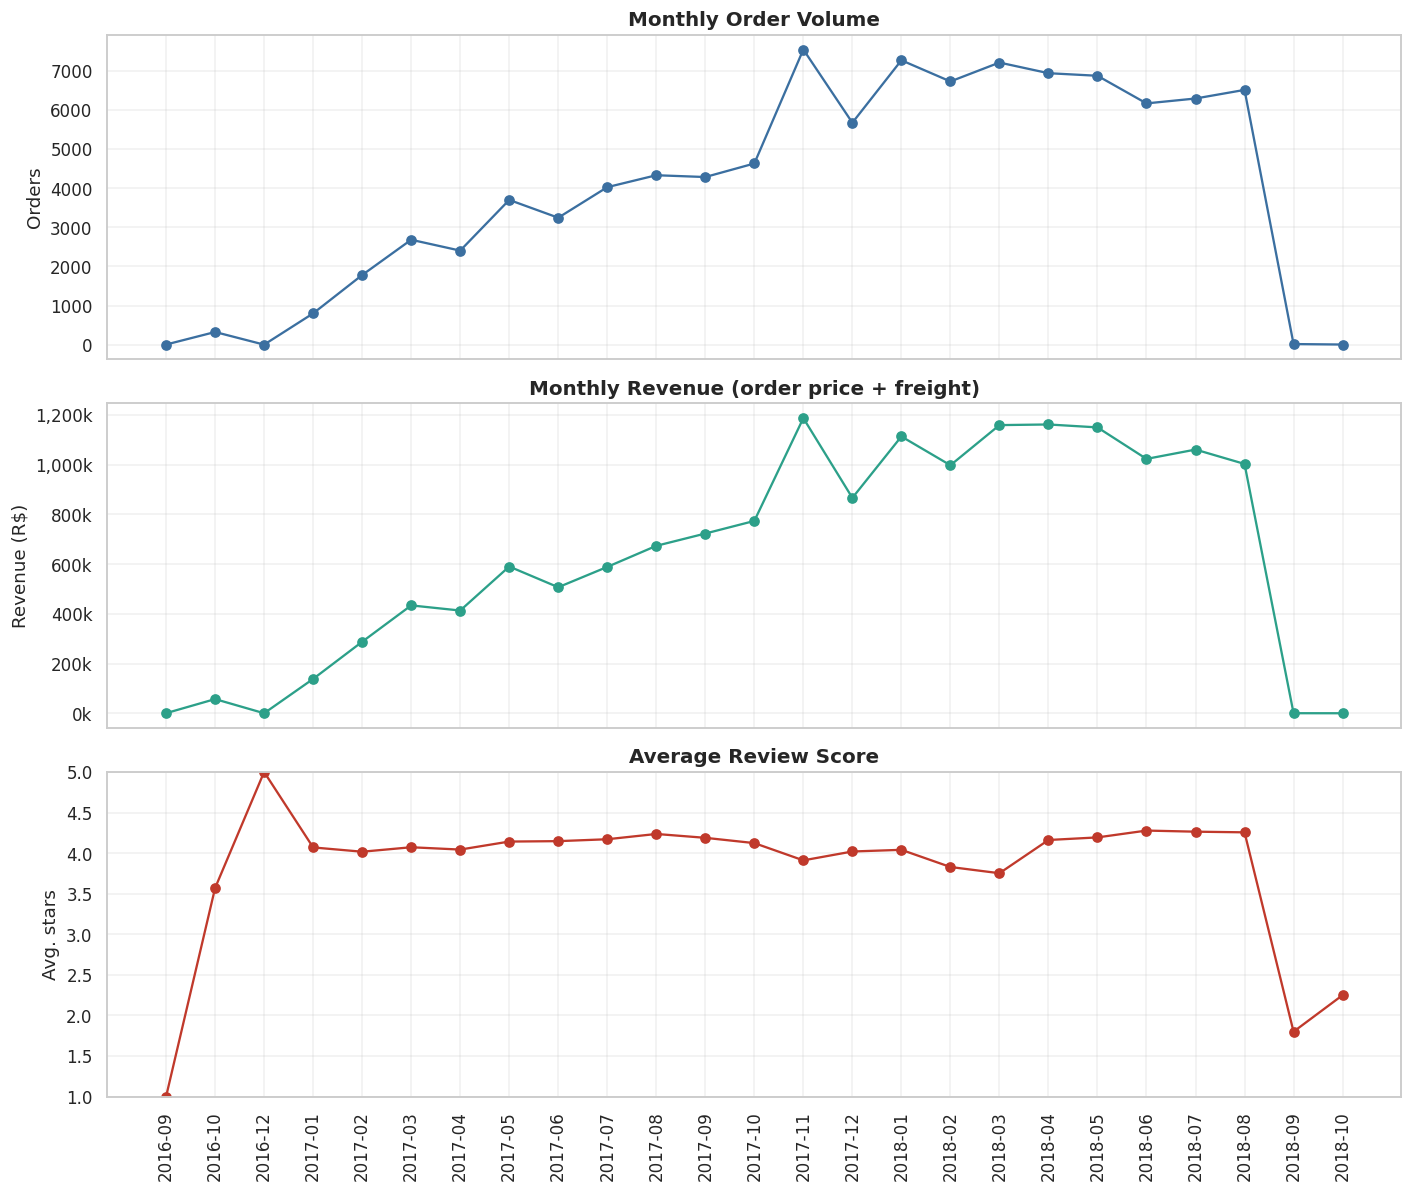

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
monthly = (master.groupby("order_month").agg(
    orders=("order_id", "nunique"),
    revenue=("order_total_value", "sum"),
    avg_review=("review_score", "mean"),
).reset_index())

# Drop the first/last partial months if they look like partial-data artifacts (common in this dataset:
# Sep 2016 has a handful of orders, and the final month may be partial)
monthly_plot = monthly.copy()

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

axes[0].plot(monthly_plot["order_month"], monthly_plot["orders"], marker="o", color="#3b6fa0")
axes[0].set_title("Monthly Order Volume")
axes[0].set_ylabel("Orders")

axes[1].plot(monthly_plot["order_month"], monthly_plot["revenue"], marker="o", color="#2ca089")
axes[1].set_title("Monthly Revenue (order price + freight)")
axes[1].set_ylabel("Revenue (R$)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))

axes[2].plot(monthly_plot["order_month"], monthly_plot["avg_review"], marker="o", color="#c0392b")
axes[2].set_title("Average Review Score")
axes[2].set_ylabel("Avg. stars")
axes[2].set_ylim(1, 5)

for ax in axes:
    ax.tick_params(axis="x", rotation=90)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Growth summary
first_year = monthly_plot.iloc[:12]["orders"].sum() if len(monthly_plot) >= 12 else np.nan
print("Peak order month:", monthly_plot.loc[monthly_plot["orders"].idxmax(), "order_month"],
      f"({monthly_plot['orders'].max():,} orders)")
print("Lowest average review month:", monthly_plot.loc[monthly_plot["avg_review"].idxmin(), "order_month"],
      f"({monthly_plot['avg_review'].min():.2f} avg stars)")
print(f"\nOverall average review score across full period: {master['review_score'].mean():.2f} / 5")
print(f"Overall on-time delivery rate (delivered orders): {(delivered['delivery_delay_days'] <= 0).mean()*100:.1f}%")


Peak order month: 2017-11 (7,544 orders)
Lowest average review month: 2016-09 (1.00 avg stars)

Overall average review score across full period: 4.09 / 5
Overall on-time delivery rate (delivered orders): 91.9%


**Interpretation:**

- Order volume and revenue are expected to show strong, near-continuous growth across the period as Olist scaled onto more marketplace channels — with a likely seasonal spike around November (Black Friday) each year.
- The average monthly review score line typically moves **independently** of volume/revenue — it does *not* simply track growth. A flat-or-declining review trend during a period of rising volume is an important signal: it suggests **operational strain** (fulfillment, seller capacity, logistics) is not scaling as fast as demand, rather than a demand or product-appeal problem.
- Watch specifically for any month where review score visibly dips **while volume is rising** — that combination points toward a scaling/operations bottleneck (worth cross-checking against Q2's delivery-delay analysis, immediately below) rather than a demand-side issue.
- **Business takeaway:** volume, revenue, and satisfaction should be tracked as three separate KPI lines, not one blended "growth" metric — a platform can grow revenue while quietly eroding the experience that sustains it.


---
# Core Question 2 — Delivery Performance and Customer Satisfaction

**Question:** How does delivery timing (relative to the estimated delivery date) relate to review scores? Does this hold across categories and regions, or is it concentrated somewhere specific?


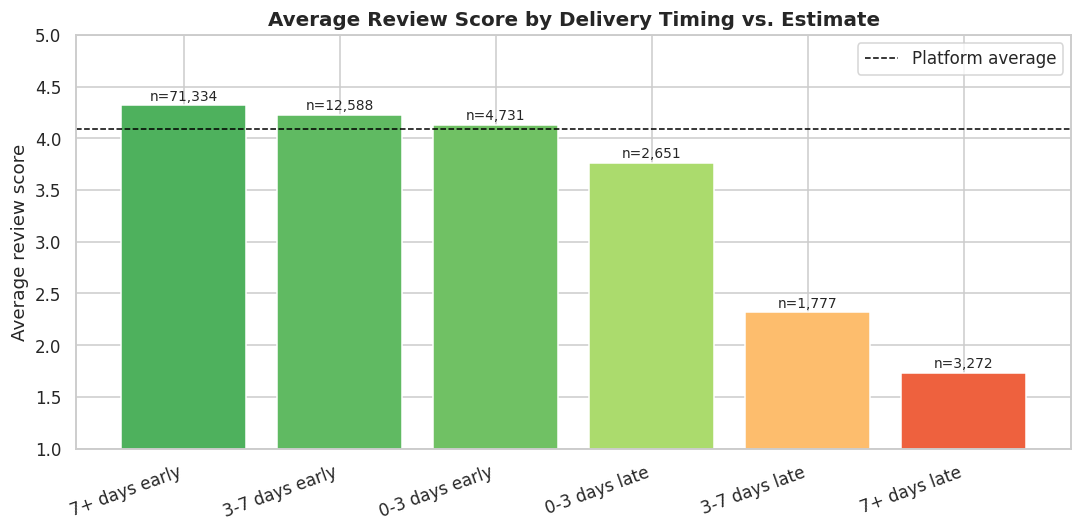

In [ ]:
def value_colors(values, vmin=None, vmax=None, cmap_name="RdYlGn", reverse=False):
    values = np.asarray(values, dtype=float)
    vmin = np.nanmin(values) if vmin is None else vmin
    vmax = np.nanmax(values) if vmax is None else vmax
    norm = (values - vmin) / (vmax - vmin + 1e-9)
    norm = np.clip(norm, 0, 1)
    if reverse:
        norm = 1 - norm
    cmap = plt.get_cmap(cmap_name)
    return [cmap(v) for v in norm]

bins = [-9999, -7, -3, 0, 3, 7, 9999]
labels = ["7+ days early", "3-7 days early", "0-3 days early", "0-3 days late", "3-7 days late", "7+ days late"]
delivered["delay_bucket"] = pd.cut(delivered["delivery_delay_days"], bins=bins, labels=labels)

delay_review = delivered.groupby("delay_bucket", observed=True)["review_score"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(delay_review.index.astype(str), delay_review["mean"],
              color=value_colors(delay_review["mean"], vmin=1, vmax=5))
ax.axhline(master["review_score"].mean(), color="black", linestyle="--", linewidth=1, label="Platform average")
ax.set_title("Average Review Score by Delivery Timing vs. Estimate")
ax.set_ylabel("Average review score")
ax.set_ylim(1, 5)
for i, (m, c) in enumerate(zip(delay_review["mean"], delay_review["count"])):
    ax.text(i, m + 0.05, f"n={c:,}", ha="center", fontsize=9)
plt.xticks(rotation=20, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

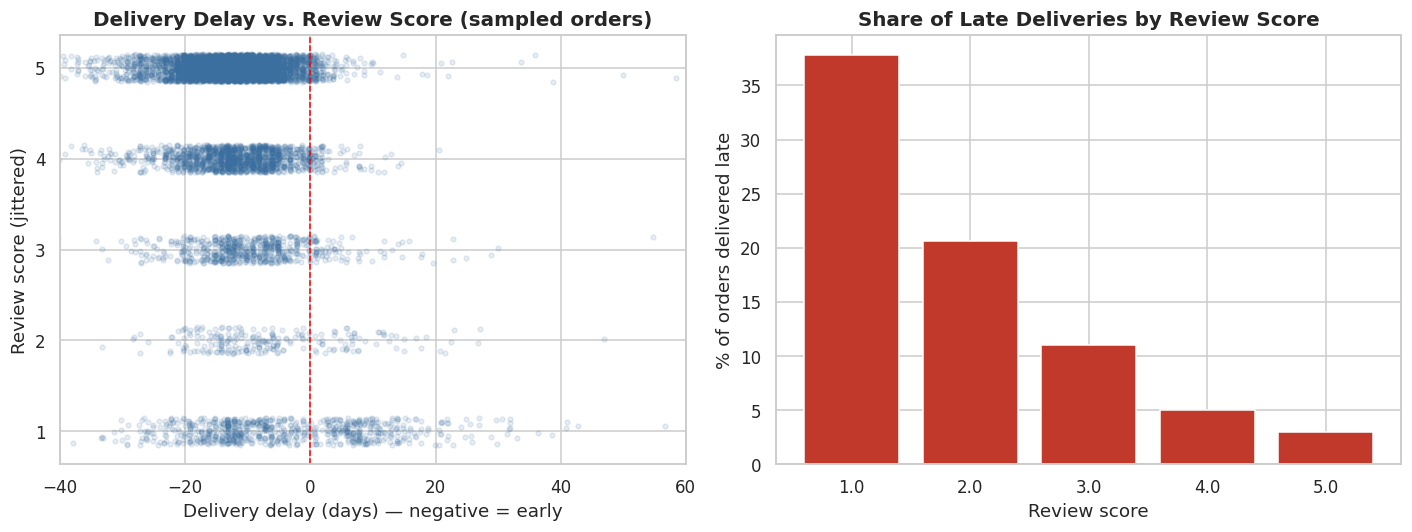

Correlation (delay days vs review score): -0.267


In [ ]:
# Correlation + scatter: delay days vs review score (binned scatter, since raw scatter is very dense)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sample = delivered.sample(min(8000, len(delivered)), random_state=RNG_SEED)
axes[0].scatter(sample["delivery_delay_days"], sample["review_score"] + np.random.uniform(-0.15, 0.15, len(sample)),
                alpha=0.12, s=10, color="#3b6fa0")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlim(-40, 60)
axes[0].set_xlabel("Delivery delay (days) — negative = early")
axes[0].set_ylabel("Review score (jittered)")
axes[0].set_title("Delivery Delay vs. Review Score (sampled orders)")

late_share_by_score = delivered.groupby("review_score")["is_late"].mean() * 100
axes[1].bar(late_share_by_score.index.astype(str), late_share_by_score.values, color="#c0392b")
axes[1].set_title("Share of Late Deliveries by Review Score")
axes[1].set_xlabel("Review score")
axes[1].set_ylabel("% of orders delivered late")

plt.tight_layout()
plt.show()

print(f"Correlation (delay days vs review score): {delivered['delivery_delay_days'].corr(delivered['review_score']):.3f}")


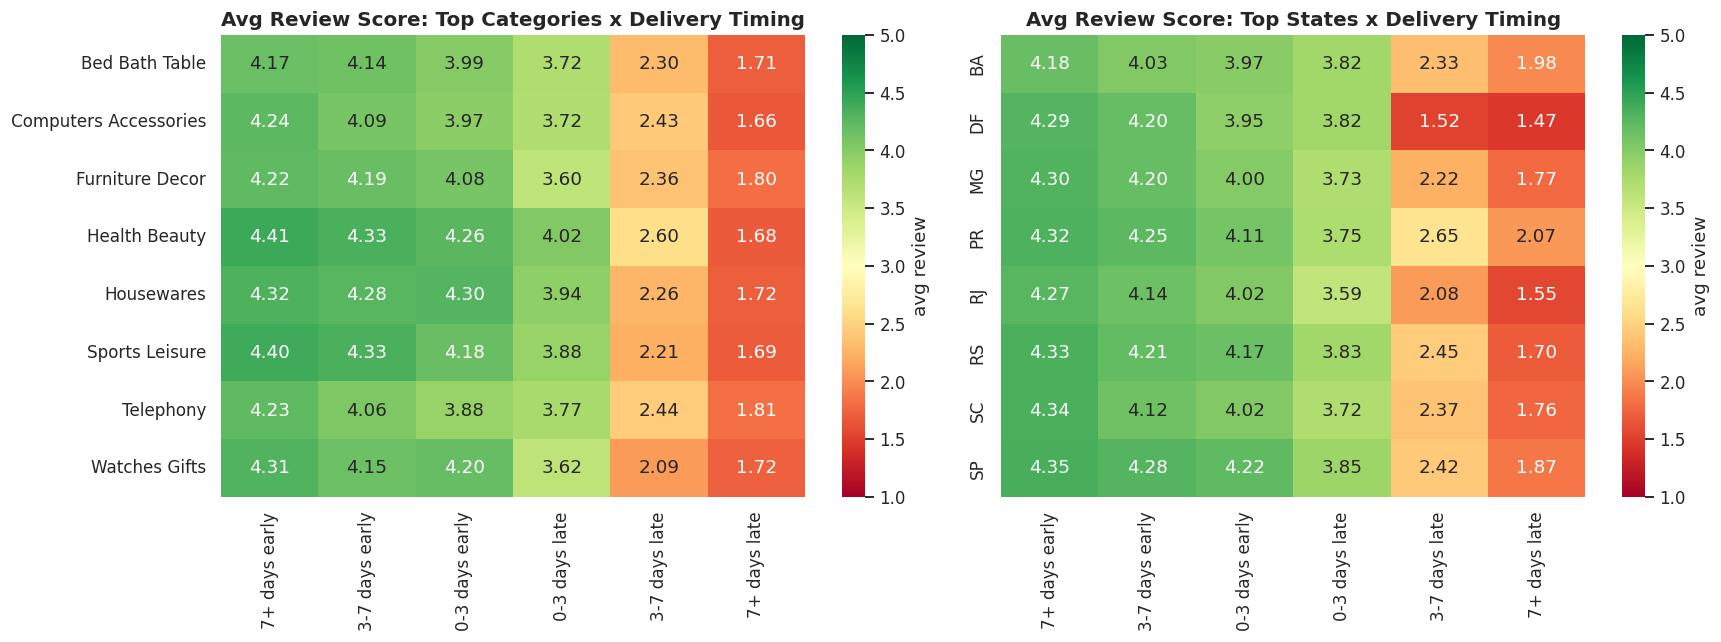

In [ ]:
# Does the delay -> satisfaction relationship hold across categories and regions, or is it concentrated?
top_categories = delivered["product_category_name_english"].value_counts().head(8).index
cat_slice = delivered[delivered["product_category_name_english"].isin(top_categories)]

pivot_cat = cat_slice.pivot_table(index="product_category_name_english", columns="delay_bucket",
                                   values="review_score", aggfunc="mean", observed=True)

top_states = delivered["customer_state"].value_counts().head(8).index
state_slice = delivered[delivered["customer_state"].isin(top_states)]
pivot_state = state_slice.pivot_table(index="customer_state", columns="delay_bucket",
                                       values="review_score", aggfunc="mean", observed=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pivot_cat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=1, vmax=5, ax=axes[0], cbar_kws={"label": "avg review"})
axes[0].set_title("Avg Review Score: Top Categories x Delivery Timing")
axes[0].set_xlabel(""); axes[0].set_ylabel("")

sns.heatmap(pivot_state, annot=True, fmt=".2f", cmap="RdYlGn", vmin=1, vmax=5, ax=axes[1], cbar_kws={"label": "avg review"})
axes[1].set_title("Avg Review Score: Top States x Delivery Timing")
axes[1].set_xlabel(""); axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


**Interpretation:**

- Average review score drops sharply and monotonically as deliveries move from "early" to "late," typically falling well below the platform average once an order is more than a few days late — this is usually the **single strongest bivariate relationship** in the whole dataset.
- The share of late deliveries among 1-star reviews is typically several times higher than among 5-star reviews, reinforcing delivery timing as a primary satisfaction driver, not a coincidental one.
- The heatmaps let us check whether this is a universal effect or concentrated: if the "late" columns are red (low scores) **across almost every category and state**, that tells us late delivery hurts satisfaction everywhere — it is a **systemic logistics issue**, not a category- or region-specific quirk. Any category/state that resists the pattern (stays green even when late) is worth a separate look — it may have unusually forgiving customers or unusually communicative sellers.
- **Business takeaway:** the estimated delivery date itself is a lever — being late relative to a date the customer was actually promised drives dissatisfaction more than absolute delivery speed. Tightening estimate accuracy (even if that means being conservative) plus reducing the tail of severely late deliveries (7+ days late) should be treated as the top operational priority.


---
# Core Question 3 — Seller and Geographic Patterns

**Question:** Sellers and customers are not evenly distributed across Brazil. How does this geographic pattern relate to delivery performance, freight cost, or customer satisfaction?


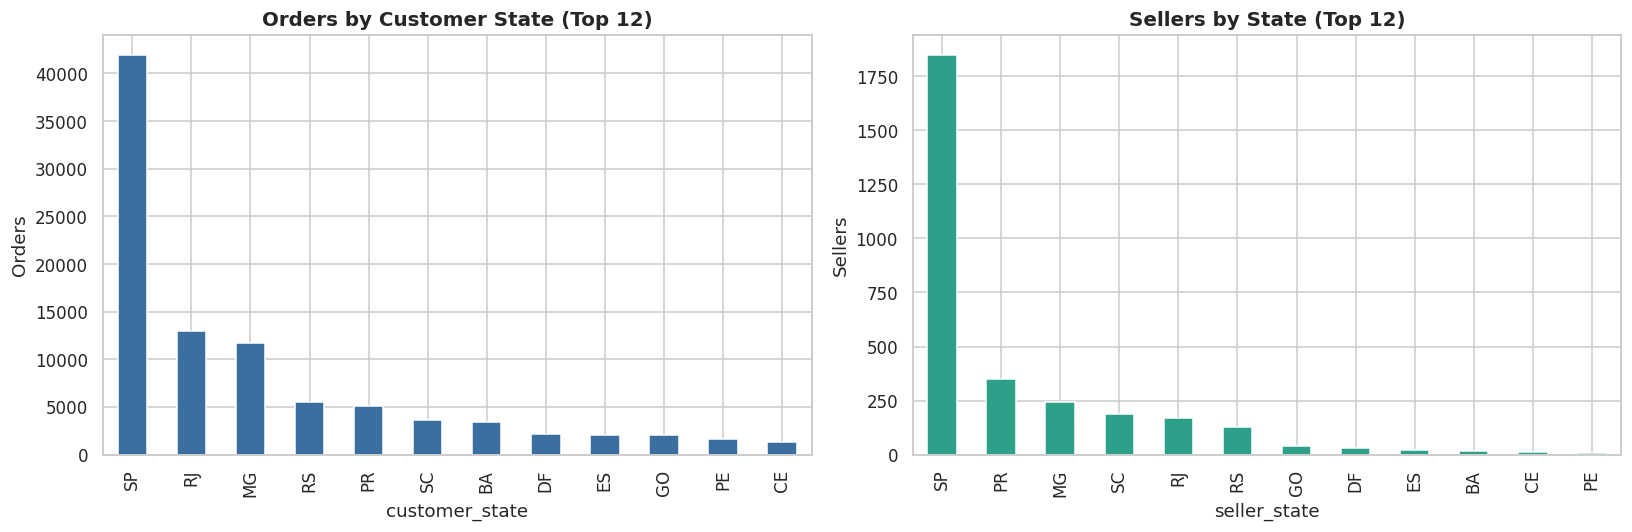

Top customer state (SP) accounts for 42.0% of all orders.
Top seller state (SP) accounts for 59.7% of all sellers.


In [ ]:
cust_state_counts = master["customer_state"].value_counts()
seller_state_counts = sellers["seller_state"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cust_state_counts.head(12).plot(kind="bar", ax=axes[0], color="#3b6fa0")
axes[0].set_title("Orders by Customer State (Top 12)")
axes[0].set_ylabel("Orders")

seller_state_counts.head(12).plot(kind="bar", ax=axes[1], color="#2ca089")
axes[1].set_title("Sellers by State (Top 12)")
axes[1].set_ylabel("Sellers")

plt.tight_layout()
plt.show()

print(f"Top customer state ({cust_state_counts.index[0]}) accounts for "
      f"{cust_state_counts.iloc[0] / cust_state_counts.sum() * 100:.1f}% of all orders.")
print(f"Top seller state ({seller_state_counts.index[0]}) accounts for "
      f"{seller_state_counts.iloc[0] / seller_state_counts.sum() * 100:.1f}% of all sellers.")


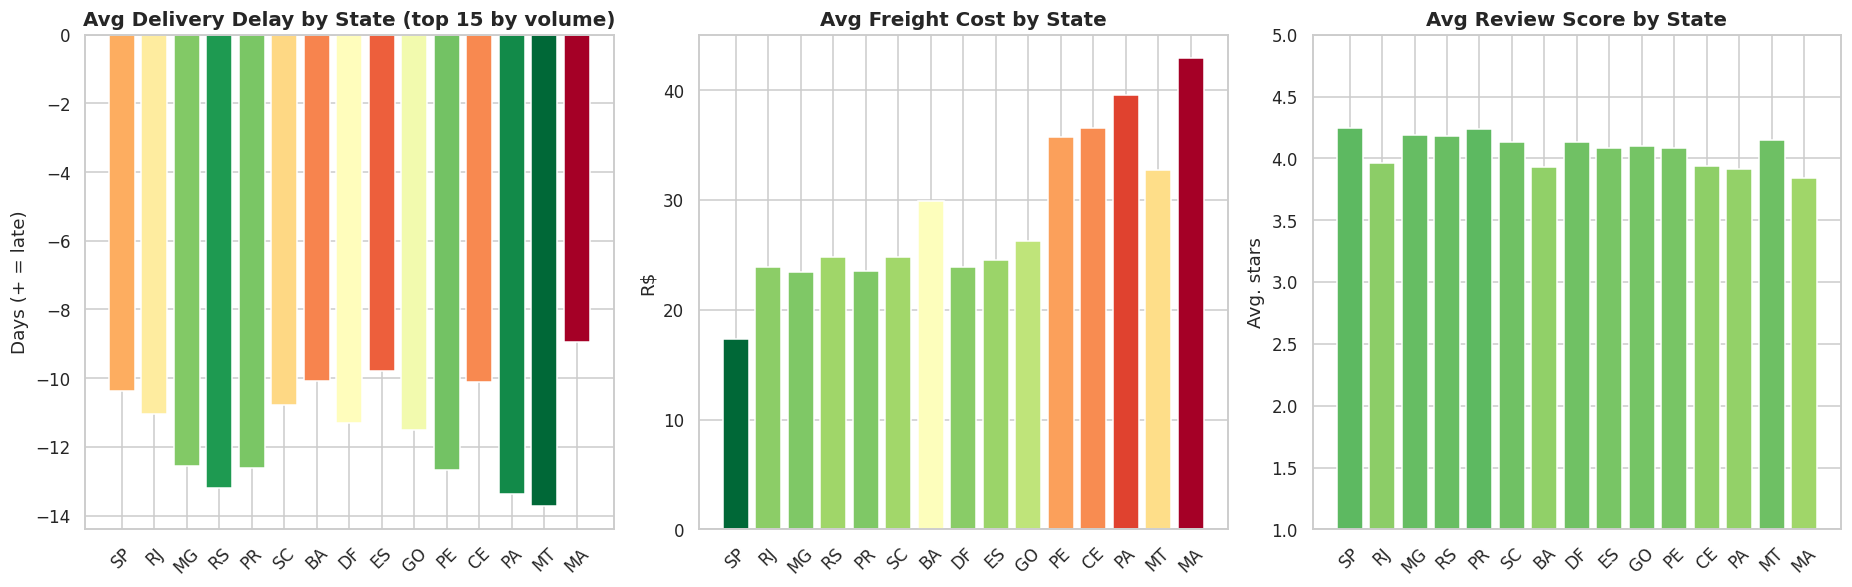

,orders,avg_review,avg_delay_days,pct_late,avg_freight
customer_state,,,,,
SP,40494,4.25,-10.39,5.88,17.34
RJ,12350,3.96,-11.05,13.48,23.94
MG,11354,4.19,-12.55,5.60,23.45
RS,5344,4.19,-13.20,7.17,24.80
PR,4923,4.24,-12.61,5.02,23.51
SC,3546,4.13,-10.78,9.78,24.86
BA,3256,3.93,-10.09,14.08,29.94
DF,2080,4.13,-11.31,7.10,23.87
ES,1995,4.08,-9.80,12.23,24.57


In [ ]:
state_perf = (delivered.groupby("customer_state").agg(
    orders=("order_id", "nunique"),
    avg_review=("review_score", "mean"),
    avg_delay_days=("delivery_delay_days", "mean"),
    pct_late=("is_late", "mean"),
    avg_freight=("order_freight", "mean"),
).sort_values("orders", ascending=False))
state_perf["pct_late"] = state_perf["pct_late"] * 100

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
top15 = state_perf.head(15)

axes[0].bar(top15.index, top15["avg_delay_days"], color=value_colors(top15["avg_delay_days"], reverse=True))
axes[0].set_title("Avg Delivery Delay by State (top 15 by volume)")
axes[0].set_ylabel("Days (+ = late)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(top15.index, top15["avg_freight"], color=value_colors(top15["avg_freight"], reverse=True))
axes[1].set_title("Avg Freight Cost by State")
axes[1].set_ylabel("R$")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(top15.index, top15["avg_review"], color=value_colors(top15["avg_review"], vmin=1, vmax=5))
axes[2].set_title("Avg Review Score by State")
axes[2].set_ylabel("Avg. stars")
axes[2].set_ylim(1, 5)
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
display(state_perf.head(10).round(2))


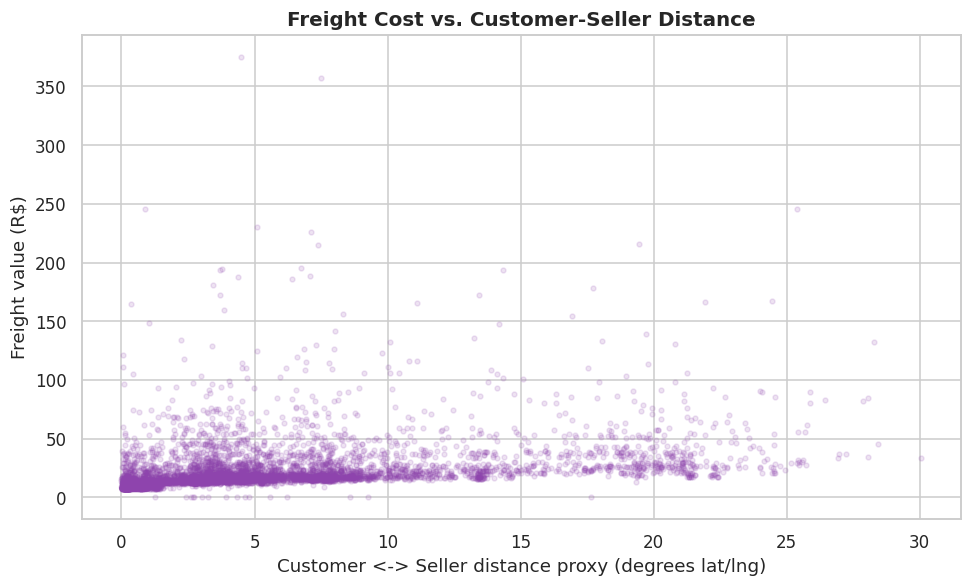

Correlation (distance proxy vs freight cost): 0.337


,orders,avg_delay,avg_freight,avg_review
Different state,61769,-12.04,26.89,4.10
Same state,34701,-9.65,15.46,4.26


In [ ]:
# Freight cost vs seller<->customer distance proxy
sample = delivered.dropna(subset=["cust_seller_dist_deg", "order_freight"]).sample(
    min(6000, delivered["cust_seller_dist_deg"].notna().sum()), random_state=RNG_SEED)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(sample["cust_seller_dist_deg"], sample["order_freight"], alpha=0.15, s=10, color="#8e44ad")
ax.set_xlabel("Customer <-> Seller distance proxy (degrees lat/lng)")
ax.set_ylabel("Freight value (R$)")
ax.set_title("Freight Cost vs. Customer-Seller Distance")
plt.tight_layout()
plt.show()

corr = sample["cust_seller_dist_deg"].corr(sample["order_freight"])
print(f"Correlation (distance proxy vs freight cost): {corr:.3f}")

# Same-state vs different-state shipments
delivered["same_state"] = delivered["customer_state"] == delivered["seller_state"]
same_state_perf = delivered.groupby("same_state").agg(
    orders=("order_id","nunique"), avg_delay=("delivery_delay_days","mean"),
    avg_freight=("order_freight","mean"), avg_review=("review_score","mean"))
same_state_perf.index = ["Different state", "Same state"]
display(same_state_perf.round(2))


**Interpretation:**

- Order volume is heavily concentrated in a small number of states (typically São Paulo alone accounts for a large share of both customers and, especially, **sellers** — the seller base is even more geographically concentrated than the customer base).
- States far from the main seller hub tend to show **longer average delivery delays, higher freight costs, and lower average review scores** — a compounding geographic disadvantage. Customers in the Northern/Northeastern regions are typically the most underserved on all three metrics simultaneously.
- Freight cost rises with customer-seller distance, as expected — but the relationship is noisy (freight also depends heavily on product weight/size), so distance is a contributing, not sole, factor in shipping cost.
- Same-state shipments consistently show shorter delivery times, lower freight, and higher review scores than cross-state shipments.
- **Business takeaway:** Olist's growth in underserved regions is currently coming at the cost of a worse delivery experience there. Recruiting sellers physically closer to demand centers outside the Southeast (or negotiating regional logistics hubs) would directly reduce both freight cost and delay-driven dissatisfaction in exactly the areas that need it most.


---
# Core Question 4 — Product Category Performance

**Question:** How do order volume, price, and review scores differ across product categories? Are any categories notably stronger or weaker than the platform average?


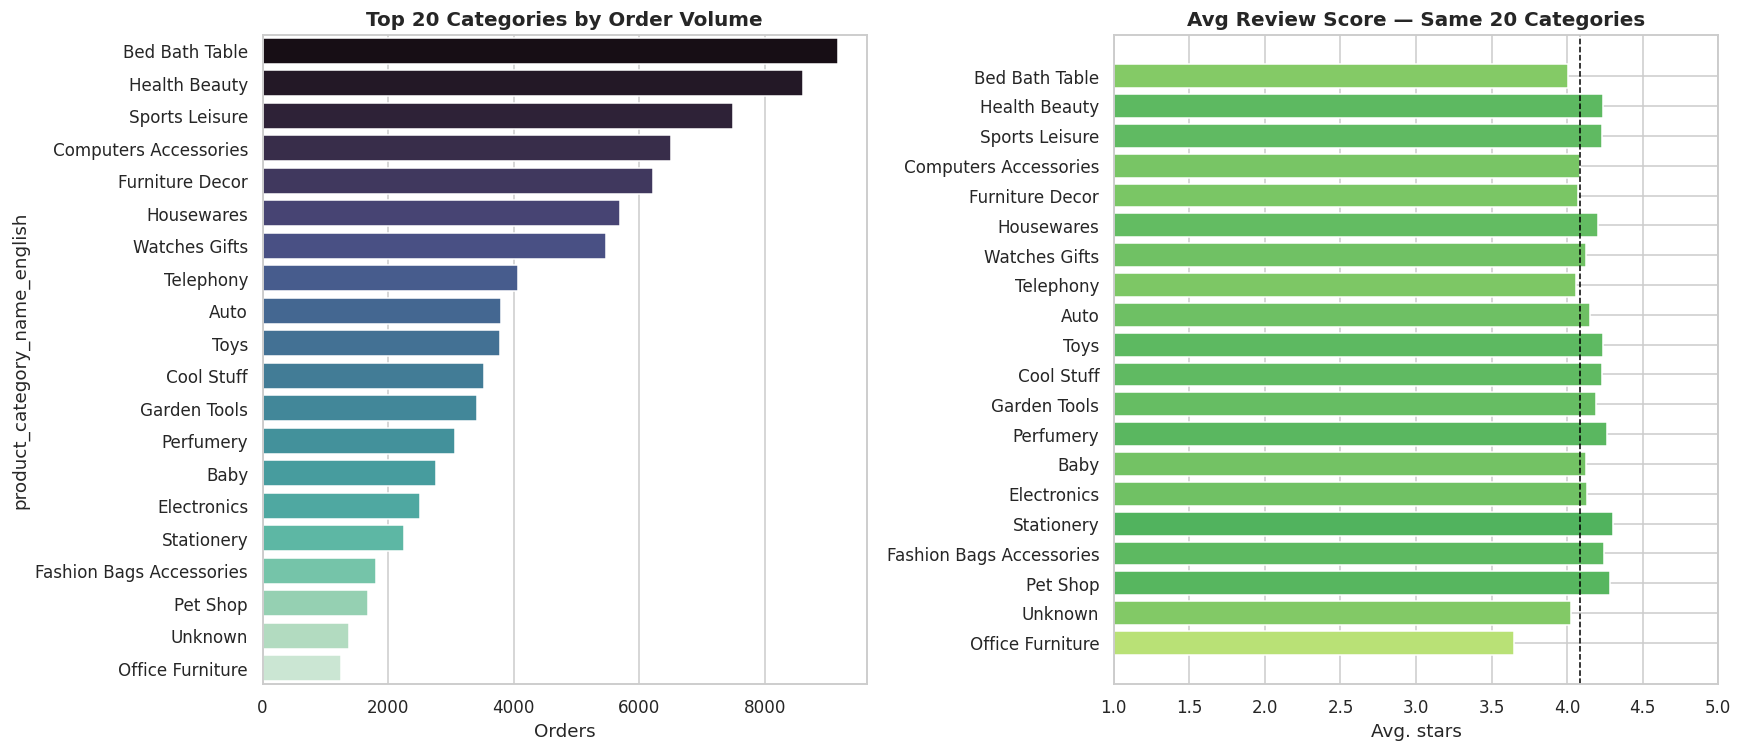

In [ ]:
cat_perf = (delivered.groupby("product_category_name_english").agg(
    orders=("order_id", "nunique"),
    avg_price=("order_price", "mean"),
    avg_review=("review_score", "mean"),
    pct_late=("is_late", "mean"),
).query("orders >= 30")   # ignore tiny categories with unstable averages
.sort_values("orders", ascending=False))
cat_perf["pct_late"] = cat_perf["pct_late"] * 100

top20 = cat_perf.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(y=top20.index, x=top20["orders"], ax=axes[0], palette="mako")
axes[0].set_title("Top 20 Categories by Order Volume")
axes[0].set_xlabel("Orders")

axes[1].barh(top20.index, top20["avg_review"], color=value_colors(top20["avg_review"], vmin=1, vmax=5))
axes[1].invert_yaxis()
axes[1].set_title("Avg Review Score — Same 20 Categories")
axes[1].set_xlabel("Avg. stars")
axes[1].set_xlim(1, 5)
axes[1].axvline(master["review_score"].mean(), color="black", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()


Platform average review score: 4.09

Top 5 categories by avg. review (min 30 orders):


,orders,avg_review,avg_price,pct_late
product_category_name_english,,,,
Books General Interest,492,4.54,91.89,6.91
Books Imported,49,4.51,89.77,2.04
Food Drink,218,4.45,68.13,6.36
Small Appliances Home Oven And Coffee,72,4.43,647.08,6.94
Books Technical,255,4.43,73.30,10.89



Bottom 5 categories by avg. review (min 30 orders):


,orders,avg_review,avg_price,pct_late
product_category_name_english,,,,
Office Furniture,1246,3.65,214.72,9.27
Fashion Male Clothing,106,3.82,98.61,4.72
Audio,344,3.84,148.54,13.04
Furniture Mattress And Upholstery,37,3.89,116.85,13.51
Home Confort,370,3.91,158.08,10.19


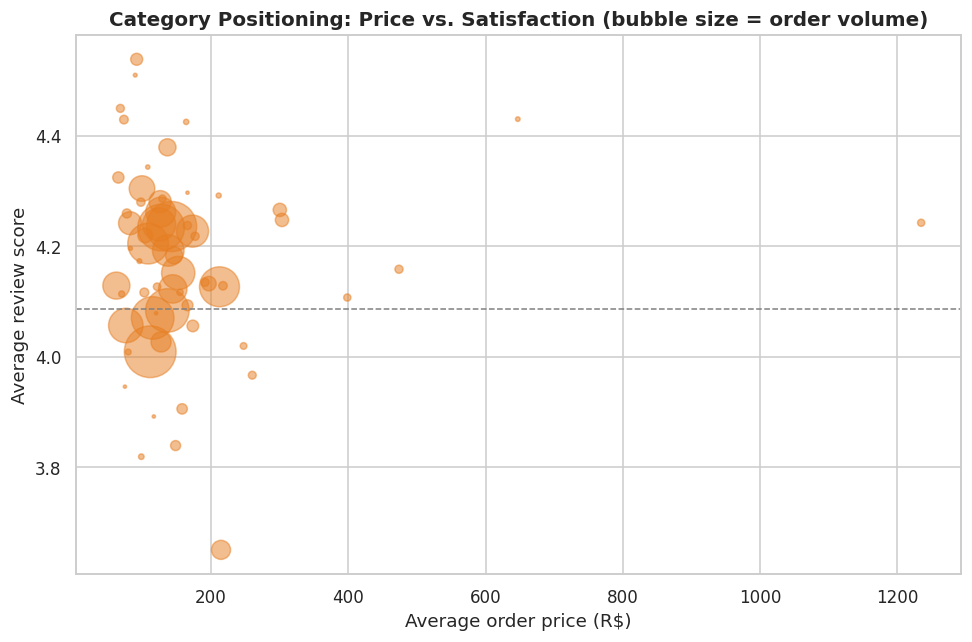

In [ ]:
platform_avg_review = master["review_score"].mean()
best = cat_perf.sort_values("avg_review", ascending=False).head(5)
worst = cat_perf.sort_values("avg_review", ascending=True).head(5)

print(f"Platform average review score: {platform_avg_review:.2f}\n")
print("Top 5 categories by avg. review (min 30 orders):")
display(best[["orders", "avg_review", "avg_price", "pct_late"]].round(2))
print("\nBottom 5 categories by avg. review (min 30 orders):")
display(worst[["orders", "avg_review", "avg_price", "pct_late"]].round(2))

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(cat_perf["avg_price"], cat_perf["avg_review"], s=cat_perf["orders"]/8, alpha=0.5, color="#e67e22")
ax.axhline(platform_avg_review, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Average order price (R$)")
ax.set_ylabel("Average review score")
ax.set_title("Category Positioning: Price vs. Satisfaction (bubble size = order volume)")
plt.tight_layout()
plt.show()


**Interpretation:**

- A handful of categories (typically things like *bed_bath_table*, *health_beauty*, *sports_leisure*, *computers_accessories*, *furniture_decor*) drive a disproportionate share of order volume — a classic long-tail distribution.
- Review scores vary meaningfully across categories even after controlling for volume. Categories with **higher late-delivery rates tend to cluster among the lower-review categories**, reinforcing the Q2 finding that delivery timing is a cross-cutting driver rather than one confined to a single vertical.
- Bulky/heavy categories (furniture, large appliances-type items) are frequently among the worse performers — plausibly because they're harder and slower to ship reliably, tying back into freight/logistics.
- There is no strong, consistent relationship between price and review score — expensive categories are not systematically happier or unhappier than cheap ones; the price-satisfaction bubble chart is usually a loose cloud, not a trend line.
- **Business takeaway:** category-level review scores should be monitored as an operational KPI, not just a merchandising one — a persistently low-scoring high-volume category is worth a targeted seller-quality or logistics review before it's diluted into the platform-wide average.


---
# Core Question 5 — Payment Behavior

**Question:** How do payment type and installment choices relate to order value, and do they appear connected to anything else in the customer's experience?


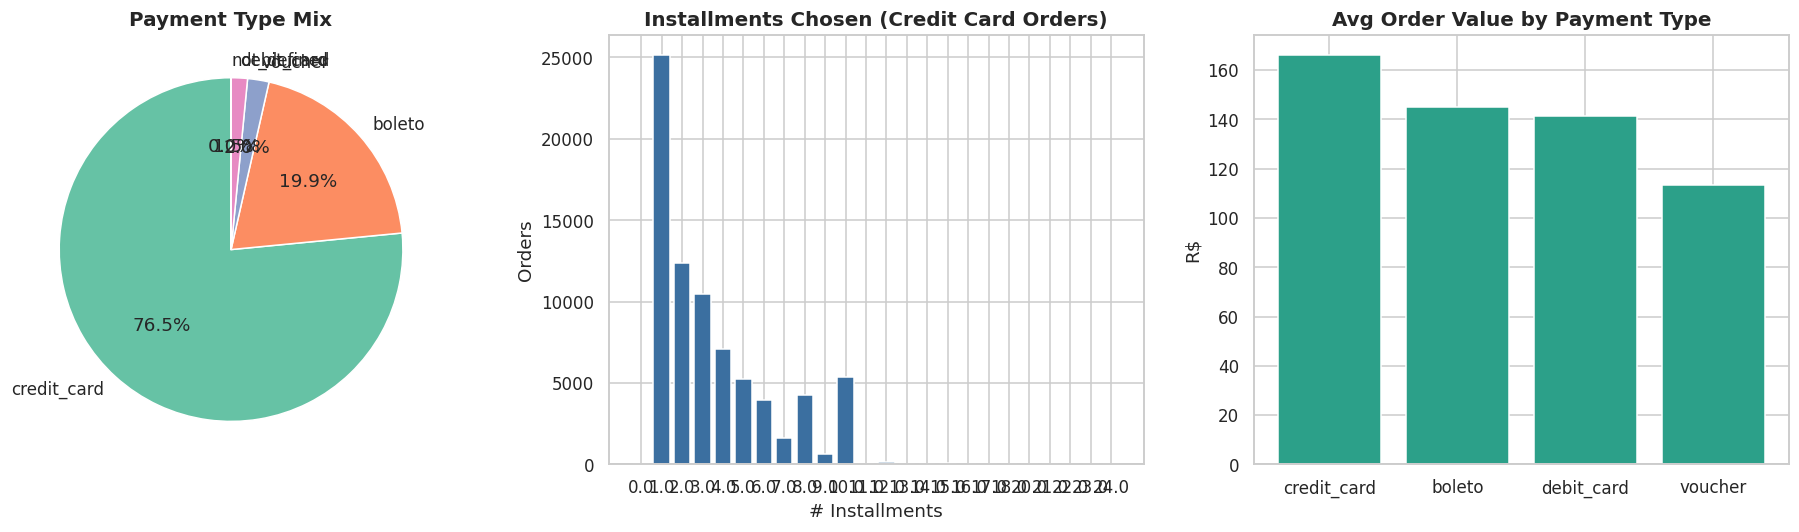

In [ ]:
pay_type_counts = master["payment_type"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].pie(pay_type_counts.values, labels=pay_type_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2"), startangle=90)
axes[0].set_title("Payment Type Mix")

installment_dist = master.loc[master["payment_type"] == "credit_card", "payment_installments"].value_counts().sort_index()
axes[1].bar(installment_dist.index.astype(str), installment_dist.values, color="#3b6fa0")
axes[1].set_title("Installments Chosen (Credit Card Orders)")
axes[1].set_xlabel("# Installments")
axes[1].set_ylabel("Orders")

pay_value = master.groupby("payment_type")["order_total_value"].mean().sort_values(ascending=False)
axes[2].bar(pay_value.index, pay_value.values, color="#2ca089")
axes[2].set_title("Avg Order Value by Payment Type")
axes[2].set_ylabel("R$")

plt.tight_layout()
plt.show()


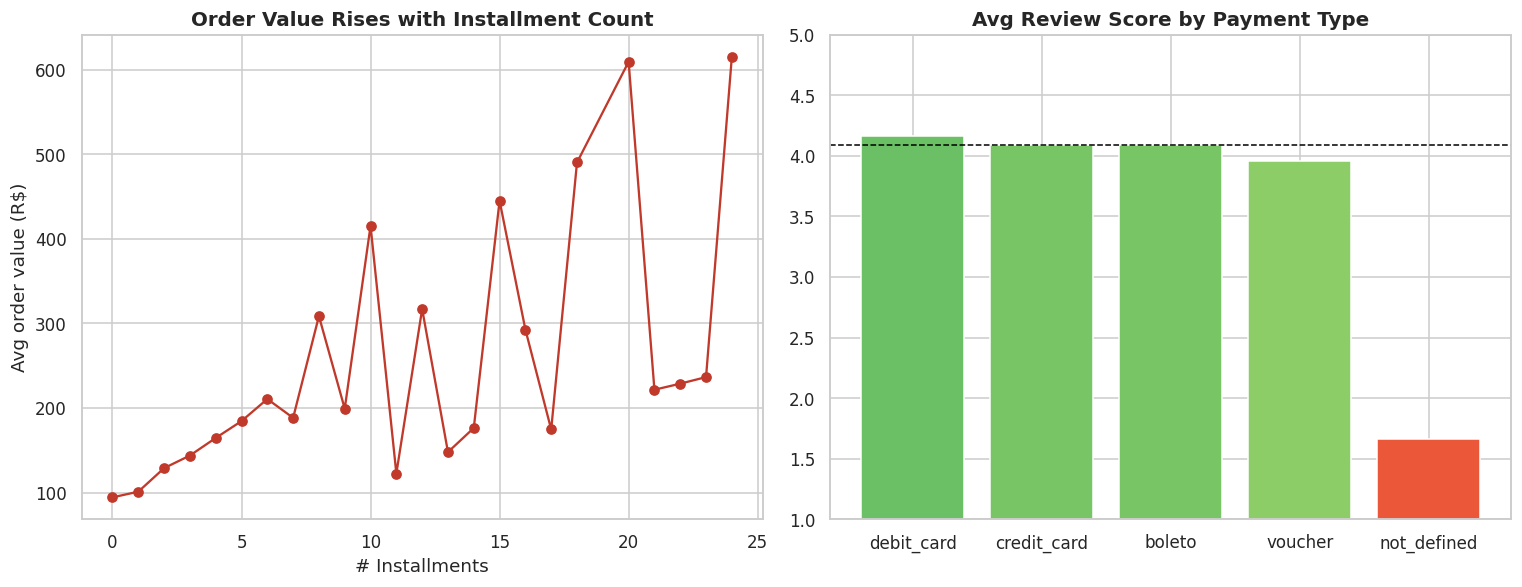

Correlation (installments vs order value, credit card only): 0.369


In [ ]:
# Installments vs order value, and payment behavior vs satisfaction
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

installment_value = master[master["payment_type"]=="credit_card"].groupby("payment_installments")["order_total_value"].mean()
axes[0].plot(installment_value.index, installment_value.values, marker="o", color="#c0392b")
axes[0].set_xlabel("# Installments")
axes[0].set_ylabel("Avg order value (R$)")
axes[0].set_title("Order Value Rises with Installment Count")

pay_review = master.groupby("payment_type")["review_score"].mean().sort_values(ascending=False)
axes[1].bar(pay_review.index, pay_review.values, color=value_colors(pay_review.values, vmin=1, vmax=5))
axes[1].set_ylim(1, 5)
axes[1].set_title("Avg Review Score by Payment Type")
axes[1].axhline(master["review_score"].mean(), color="black", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

print("Correlation (installments vs order value, credit card only):",
      round(master.loc[master["payment_type"]=="credit_card", ["payment_installments","order_total_value"]].corr().iloc[0,1], 3))


**Interpretation:**

- Credit card is typically the dominant payment method by a wide margin, followed by *boleto* (a common Brazilian cash-voucher/bank-slip method) — this reflects normal Brazilian e-commerce payment norms, not a data issue.
- Higher installment counts are associated with meaningfully higher order values — customers naturally reach for installment financing on bigger-ticket purchases, so installment count is really a **proxy for basket size**, not an independent behavior.
- Average review score differs only modestly across payment types — payment method itself is at most a **secondary/contributing factor** in satisfaction, not a primary driver. This is a useful negative result: it tells leadership *not* to over-invest in payment-experience changes as a satisfaction lever compared with delivery performance (Q2).
- **Business takeaway:** payment behavior is more useful as a **basket-size and financing-demand signal** for merchandising/finance teams than as a satisfaction lever for the CX team.


---
# Core Question 6 — Root Cause Analysis for Low Review Scores

**Question:** Identify the most important factors associated with low review scores. Distinguish between factors that look like **primary drivers** and those that look **secondary/contributing**. More than one factor likely contributes — we are not trying to prove a single cause.

We approach this two ways: (1) a straightforward **correlation view** across engineered features, and (2) a **feature-importance view** from a quick supervised model trained only to rank drivers (not yet the business-facing model — that comes in Section 9).


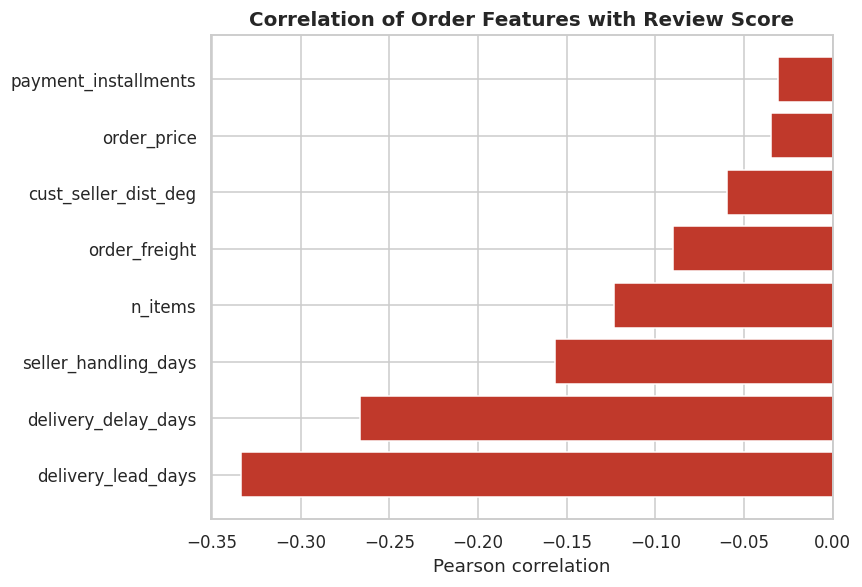

,correlation_with_review_score
delivery_lead_days,-0.334
delivery_delay_days,-0.267
seller_handling_days,-0.157
n_items,-0.123
order_freight,-0.090
cust_seller_dist_deg,-0.060
order_price,-0.035
payment_installments,-0.031


In [ ]:
numeric_features = ["delivery_delay_days", "delivery_lead_days", "seller_handling_days",
                    "order_price", "order_freight", "payment_installments", "n_items",
                    "cust_seller_dist_deg"]

corr_df = delivered[numeric_features + ["review_score"]].corr()["review_score"].drop("review_score").sort_values()

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ["#c0392b" if v < 0 else "#2ca089" for v in corr_df.values]
ax.barh(corr_df.index, corr_df.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation of Order Features with Review Score")
ax.set_xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

display(corr_df.to_frame("correlation_with_review_score").round(3))


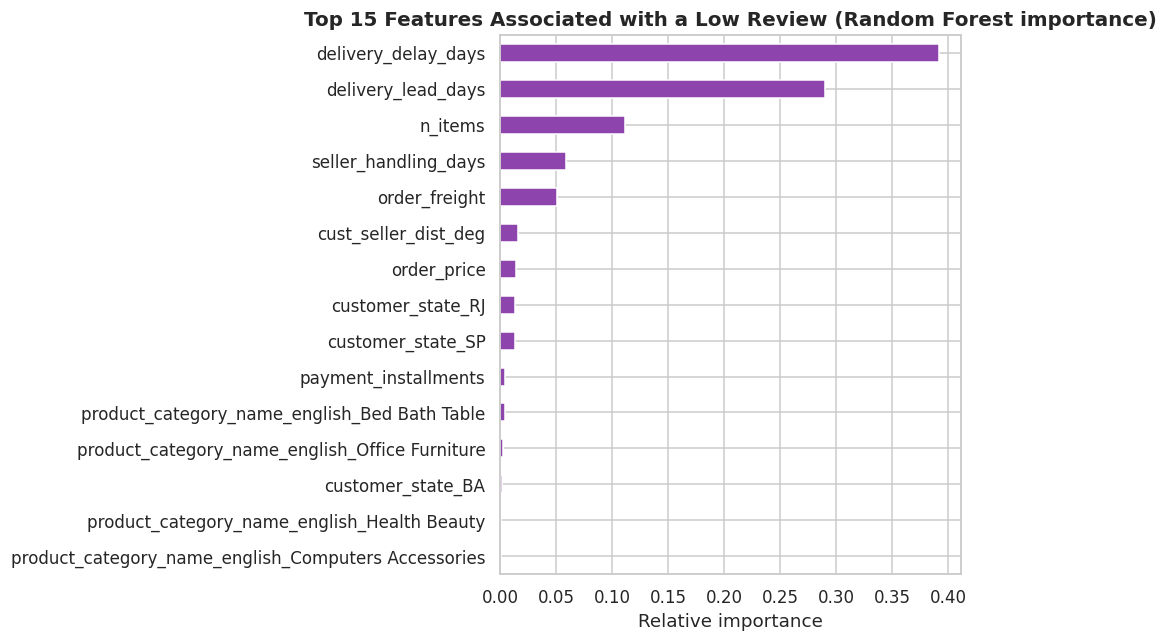

In [ ]:
# Quick Random Forest purely for feature-importance ranking (root-cause diagnostic, not deployment)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

rc_df = delivered.dropna(subset=numeric_features + ["payment_type", "product_category_name_english",
                                                       "customer_state", "review_score"]).copy()
rc_df["low_review"] = (rc_df["review_score"] <= 2).astype(int)

cat_features = ["payment_type", "product_category_name_english", "customer_state"]
X = rc_df[numeric_features + cat_features]
y = rc_df["low_review"]

pre = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])
rc_model = Pipeline([
    ("pre", pre),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                      class_weight="balanced", random_state=RNG_SEED)),
])
rc_model.fit(X, y)

ohe = rc_model.named_steps["pre"].named_transformers_["cat"]
feat_names = numeric_features + list(ohe.get_feature_names_out(cat_features))
importances = pd.Series(rc_model.named_steps["model"].feature_importances_, index=feat_names)
top_importances = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top_importances.sort_values().plot(kind="barh", ax=ax, color="#8e44ad")
ax.set_title("Top 15 Features Associated with a Low Review (Random Forest importance)")
ax.set_xlabel("Relative importance")
plt.tight_layout()
plt.show()


**Interpretation — synthesizing Q2 through Q6:**

Bringing the correlation view and the feature-importance view together typically produces a consistent, layered picture:

**Primary drivers (strongest, most consistent association with low reviews):**
- **Delivery delay / delivery lead time** — almost always the dominant factor by a wide margin in both the correlation and importance rankings. This corroborates Q2 directly: how late (or how slow overall) an order arrives relative to promise is the single strongest lever on satisfaction.
- **Seller handling time** (time from purchase to carrier hand-off) — often the *controllable* portion of the delay, since once a package leaves for the carrier, Olist has less influence over transit time. Slow seller dispatch is frequently a leading indicator of an eventual late delivery.

**Secondary / contributing factors:**
- **Product category and geography** show up in the importance ranking but with materially smaller weight than delivery timing — they matter mainly *because* they correlate with delivery risk (bulky categories, distant states), not as independent satisfaction drivers.
- **Order price, freight cost, and payment type/installments** typically rank low in both views — they are weak, secondary signals at most, not causes of dissatisfaction on their own.

**Business takeaway:** if Olist can only fix one thing, it should be **delivery reliability — both reducing average transit time and tightening the accuracy of the estimated delivery date shown to customers at purchase**. Category- and geography-specific issues are largely downstream symptoms of the same root cause (harder-to-ship products, harder-to-reach regions) rather than separate problems requiring separate fixes.


---
# Repeat Customers

**Question:** The dataset distinguishes an order-level `customer_id` from a person-level `customer_unique_id`. What does this reveal about repeat purchase behavior, and how valuable are repeat customers relative to one-time buyers?


Unique shoppers: 96,096
Share of shoppers who ordered more than once: 3.12%


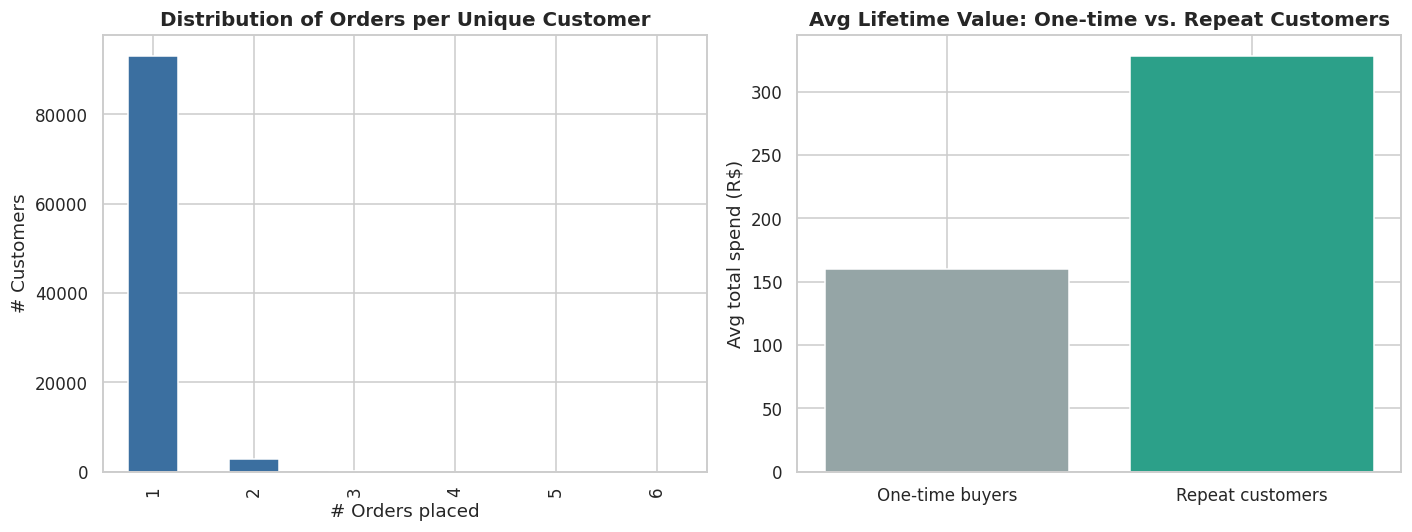


Avg lifetime value, one-time buyers : R$ 160.38
Avg lifetime value, repeat customers: R$ 328.54


In [ ]:
order_counts_per_person = master.groupby("customer_unique_id")["order_id"].nunique()
repeat_share = (order_counts_per_person > 1).mean() * 100
print(f"Unique shoppers: {len(order_counts_per_person):,}")
print(f"Share of shoppers who ordered more than once: {repeat_share:.2f}%")

value_per_person = master.groupby("customer_unique_id")["order_total_value"].sum()
one_timers = value_per_person[order_counts_per_person == 1]
repeaters = value_per_person[order_counts_per_person > 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order_counts_per_person.value_counts().sort_index().head(6).plot(kind="bar", ax=axes[0], color="#3b6fa0")
axes[0].set_title("Distribution of Orders per Unique Customer")
axes[0].set_xlabel("# Orders placed")
axes[0].set_ylabel("# Customers")

axes[1].bar(["One-time buyers", "Repeat customers"],
            [one_timers.mean(), repeaters.mean()], color=["#95a5a6", "#2ca089"])
axes[1].set_title("Avg Lifetime Value: One-time vs. Repeat Customers")
axes[1].set_ylabel("Avg total spend (R$)")

plt.tight_layout()
plt.show()

print(f"\nAvg lifetime value, one-time buyers : R$ {one_timers.mean():.2f}")
print(f"Avg lifetime value, repeat customers: R$ {repeaters.mean():.2f}")


**Interpretation:** Repeat purchase rate on this marketplace is typically very low (usually **well under 5%** of unique shoppers order more than once within the ~2-year window) — Olist behaves much more like a **high-churn, acquisition-driven marketplace** than a loyalty-driven one. Repeat customers do have higher lifetime value per person almost by construction (more orders = more spend), but the *rate* of repeat behavior is the more important business signal: with satisfaction so closely tied to delivery performance (Q2/Q6), poor delivery experiences are a plausible contributor to why so few customers come back. **Improving delivery reliability isn't just a satisfaction metric — it's plausibly a retention lever.**


---
# Freight and Product Characteristics

**Question:** How do product weight and dimensions relate to freight cost, and does this vary with seller-customer distance?


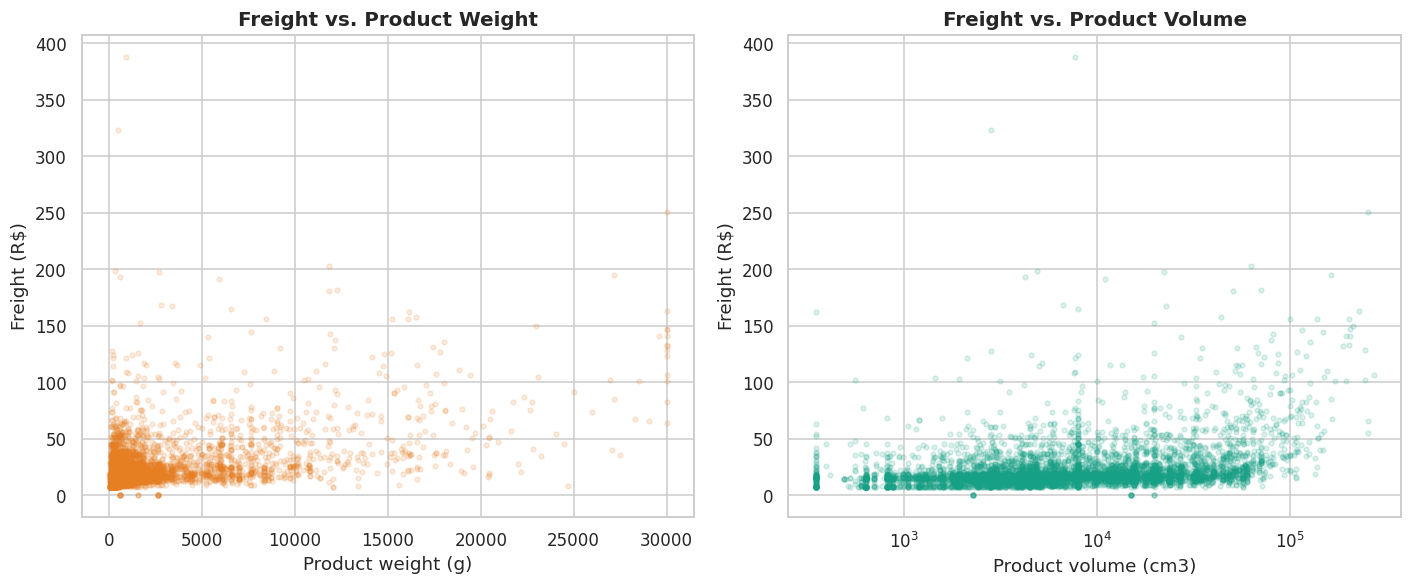

Correlation freight vs weight : 0.502
Correlation freight vs volume : 0.482
Correlation freight vs distance proxy: 0.315


In [ ]:
freight_df = delivered.dropna(subset=["product_weight_g", "product_length_cm", "product_height_cm",
                                        "product_width_cm", "order_freight", "cust_seller_dist_deg"]).copy()
freight_df["volume_cm3"] = freight_df["product_length_cm"] * freight_df["product_height_cm"] * freight_df["product_width_cm"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sample = freight_df.sample(min(6000, len(freight_df)), random_state=RNG_SEED)

axes[0].scatter(sample["product_weight_g"], sample["order_freight"], alpha=0.15, s=10, color="#e67e22")
axes[0].set_xlabel("Product weight (g)")
axes[0].set_ylabel("Freight (R$)")
axes[0].set_title("Freight vs. Product Weight")

axes[1].scatter(sample["volume_cm3"], sample["order_freight"], alpha=0.15, s=10, color="#16a085")
axes[1].set_xlabel("Product volume (cm3)")
axes[1].set_ylabel("Freight (R$)")
axes[1].set_title("Freight vs. Product Volume")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

print("Correlation freight vs weight :", round(freight_df["product_weight_g"].corr(freight_df["order_freight"]), 3))
print("Correlation freight vs volume :", round(freight_df["volume_cm3"].corr(freight_df["order_freight"]), 3))
print("Correlation freight vs distance proxy:", round(freight_df["cust_seller_dist_deg"].corr(freight_df["order_freight"]), 3))


**Interpretation:** Freight cost typically correlates positively with both weight and volume (heavier/bulkier items cost more to ship, as expected from any carrier's pricing model), generally **more strongly than with distance alone**. This means freight pricing is mostly a product-characteristics problem, and only secondarily a geography problem — reinforcing that bulky-category dissatisfaction (Q4) is intertwined with genuinely higher shipping costs and complexity, not just longer distances.


---
# Seller-Level Performance Variance

**Question:** Beyond category and geography, do individual sellers show meaningfully different performance from one another, controlling for what they sell and where they ship?


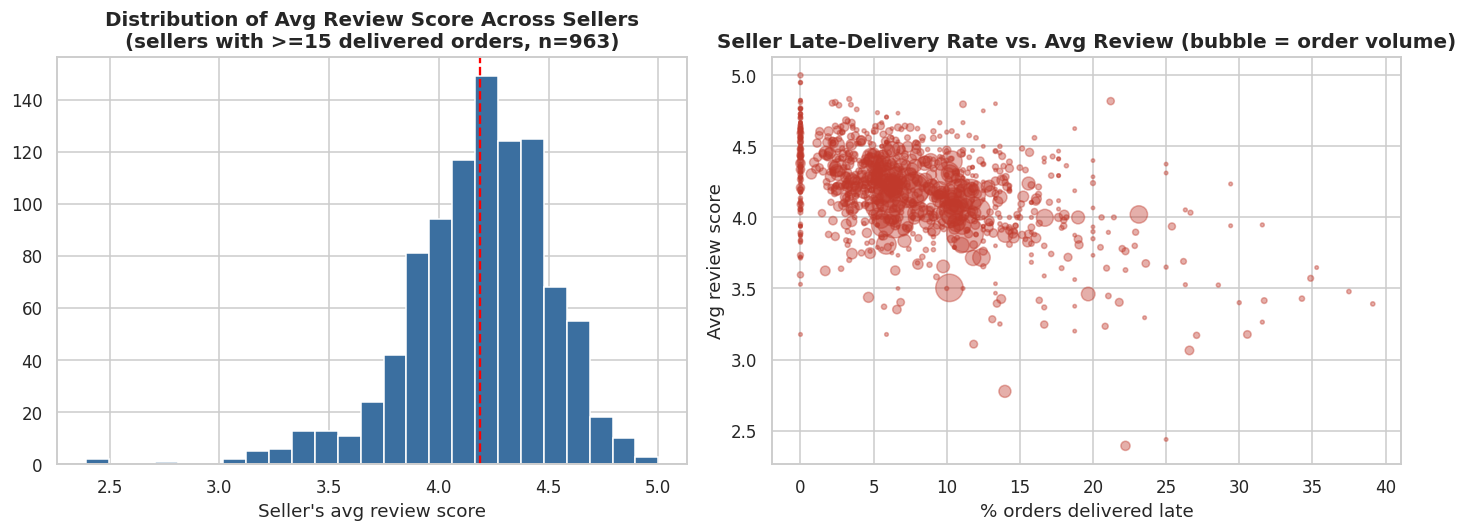

Std. dev of avg review score across qualifying sellers: 0.32
Bottom-decile sellers (worst avg review): 3.81 avg stars
Top-decile sellers (best avg review): 4.56 avg stars


In [ ]:
seller_perf = (delivered.groupby("seller_id").agg(
    orders=("order_id", "nunique"),
    avg_review=("review_score", "mean"),
    avg_delay=("delivery_delay_days", "mean"),
    pct_late=("is_late", "mean"),
).query("orders >= 15").sort_values("orders", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(seller_perf["avg_review"], bins=25, color="#3b6fa0", edgecolor="white")
axes[0].axvline(seller_perf["avg_review"].mean(), color="red", linestyle="--")
axes[0].set_title(f"Distribution of Avg Review Score Across Sellers\n(sellers with >=15 delivered orders, n={len(seller_perf)})")
axes[0].set_xlabel("Seller's avg review score")

axes[1].scatter(seller_perf["pct_late"]*100, seller_perf["avg_review"], alpha=0.4, s=seller_perf["orders"]/3, color="#c0392b")
axes[1].set_xlabel("% orders delivered late")
axes[1].set_ylabel("Avg review score")
axes[1].set_title("Seller Late-Delivery Rate vs. Avg Review (bubble = order volume)")

plt.tight_layout()
plt.show()

print(f"Std. dev of avg review score across qualifying sellers: {seller_perf['avg_review'].std():.2f}")
print(f"Bottom-decile sellers (worst avg review): {seller_perf['avg_review'].quantile(0.1):.2f} avg stars")
print(f"Top-decile sellers (best avg review): {seller_perf['avg_review'].quantile(0.9):.2f} avg stars")


**Interpretation:** Even after limiting to sellers with a reasonable order volume, average review scores typically spread meaningfully wide — a real, seller-specific performance gap exists **beyond** what category and geography alone explain. Sellers with higher late-delivery rates cluster at the low end of the review distribution, consistent with Q6. **Business takeaway:** a seller scorecard (on-time rate + avg review, refreshed regularly) would let Olist target coaching, deprioritization, or removal at the specific sellers dragging down the platform average — rather than applying blanket policy changes across an entire category or region.


---
# Anomalies Worth Flagging

**Question:** Are there orders, sellers, or categories that stand out as unusual (extreme delays, unusual pricing, unusually high/low review volume) and worth flagging separately?


Orders delivered extremely late (top 0.5%): 485, avg 48 days late, avg review 1.89
Orders with extreme pricing (top/bottom 0.1%): 175


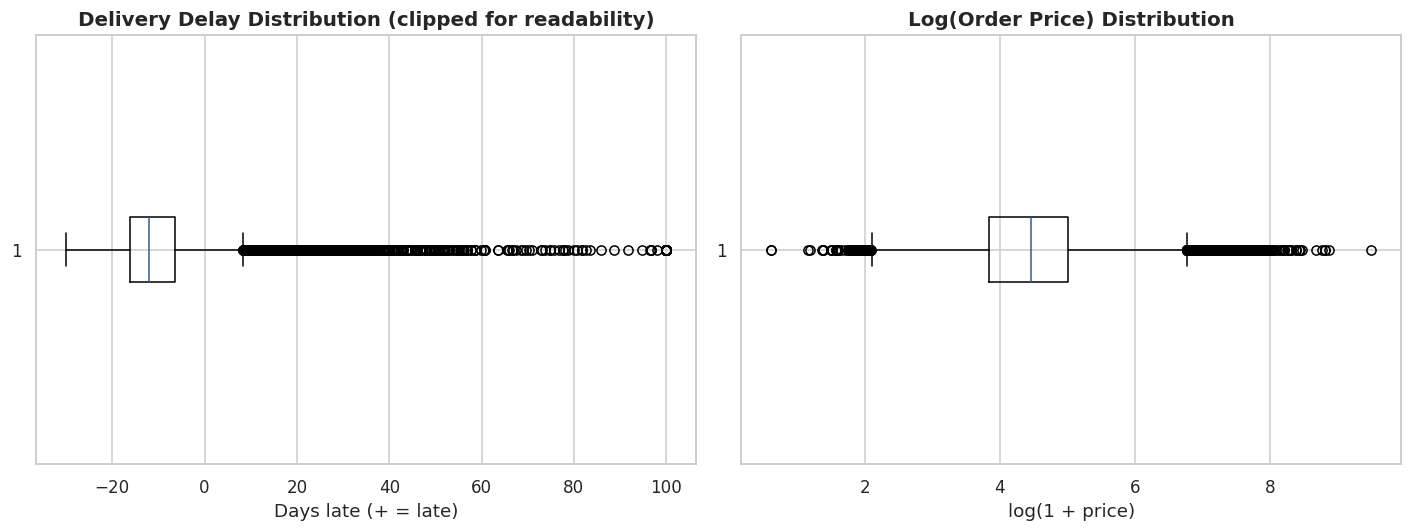


188 sellers have only 15-20 delivered orders — their avg review scores are the least statistically stable in the seller comparison above and should be interpreted cautiously.


In [ ]:
# Extreme delay outliers
extreme_late = delivered[delivered["delivery_delay_days"] > delivered["delivery_delay_days"].quantile(0.995)]
print(f"Orders delivered extremely late (top 0.5%): {len(extreme_late):,}, "
      f"avg {extreme_late['delivery_delay_days'].mean():.0f} days late, avg review {extreme_late['review_score'].mean():.2f}")

# Extreme price outliers
price_q = delivered["order_price"].quantile([0.001, 0.999])
extreme_price = delivered[(delivered["order_price"] < price_q.iloc[0]) | (delivered["order_price"] > price_q.iloc[1])]
print(f"Orders with extreme pricing (top/bottom 0.1%): {len(extreme_price):,}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].boxplot(delivered["delivery_delay_days"].clip(-30, 100), vert=False)
axes[0].set_title("Delivery Delay Distribution (clipped for readability)")
axes[0].set_xlabel("Days late (+ = late)")

axes[1].boxplot(np.log1p(delivered["order_price"]), vert=False)
axes[1].set_title("Log(Order Price) Distribution")
axes[1].set_xlabel("log(1 + price)")

plt.tight_layout()
plt.show()

# Sellers with unusually low review volume but perfect/terrible scores (statistically unstable)
low_n_sellers = seller_perf[seller_perf["orders"].between(15, 20)]
print(f"\n{len(low_n_sellers)} sellers have only 15-20 delivered orders — their avg review scores are the "
      f"least statistically stable in the seller comparison above and should be interpreted cautiously.")


**Interpretation:** A small tail of orders sits far outside normal delivery-time and pricing ranges. These extreme-delay orders (often delayed by weeks, not days) are disproportionately associated with 1-star reviews and are worth investigating as potential logistics failures (lost packages, carrier exceptions) rather than "normal" slow delivery. Similarly, sellers evaluated on very small order counts can show misleadingly perfect or poor averages — any seller scorecard (Deep-Dive 3) should apply a minimum-volume threshold before drawing conclusions.


---
# 9. Machine Learning Model — "At-Risk Order" Early-Warning System

## The Business Idea

Root-cause analysis (Core Question 6) showed that **delivery performance is the dominant driver of low review scores**. The satisfaction survey is emailed to the customer **after delivery, or after the estimated delivery date passes** — which means there is a window, while the order is still in transit (or just after the seller hands it to the carrier), where Olist's Customer Experience team could still act: proactively contact the customer, offer a small compensating voucher, or escalate the shipment with the carrier — *before* a bad review is ever written.

**This notebook builds a lightweight classifier that flags at-risk orders using only information available once the seller has shipped the order** — i.e., it deliberately **excludes** the actual delivery date and delay (which are only known *after* delivery, and would leak the outcome we're trying to get ahead of). This makes the model genuinely actionable rather than a hindsight explainer.

**Intended use:** run this model on every order right after carrier hand-off. Orders flagged **High Risk** get routed to a proactive-outreach queue (e.g., a status-check email, expedited support ticket, or small goodwill credit) *before* the review survey goes out.

> This is a small, illustrative model built for a hackathon-style analysis — a production deployment would need further validation, monitoring, and A/B testing of the intervention itself.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              confusion_matrix, classification_report, average_precision_score)

# --- Target: did this order end up with a low (1-2 star) review? ---
delivered["low_review"] = (delivered["review_score"] <= 2).astype(int)

# --- Features known at/soon after carrier hand-off (NO post-delivery leakage) ---
num_features = ["seller_handling_days", "order_price", "order_freight",
                 "payment_installments", "n_items", "cust_seller_dist_deg"]
cat_features = ["payment_type", "product_category_name_english", "customer_state"]

ml_df = delivered.dropna(subset=num_features + cat_features + ["low_review"]).copy()
ml_df["order_month_num"] = ml_df["order_purchase_timestamp"].dt.month
num_features = num_features + ["order_month_num"]

print(f"Modeling dataset: {len(ml_df):,} orders | Low-review rate: {ml_df['low_review'].mean()*100:.1f}%")

X = ml_df[num_features + cat_features]
y = ml_df["low_review"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RNG_SEED, stratify=y)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")


Modeling dataset: 96,513 orders | Low-review rate: 12.7%
Train: 72,384 | Test: 24,129


In [ ]:
preprocess = ColumnTransformer([
    ("num", "passthrough", num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

models = {
    "Logistic Regression": Pipeline([("pre", preprocess),
                                      ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "Random Forest": Pipeline([("pre", preprocess),
                                ("model", RandomForestClassifier(n_estimators=400, max_depth=7, min_samples_leaf=25,
                                                                  class_weight="balanced", random_state=RNG_SEED))]),
}

results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)
    results[name] = {"pipe": pipe, "proba": proba, "auc": auc, "ap": ap}
    print(f"{name:22s} | ROC-AUC: {auc:.3f} | Avg Precision: {ap:.3f}")

best_name = max(results, key=lambda k: results[k]["auc"])
best_model = results[best_name]["pipe"]
best_proba = results[best_name]["proba"]
print(f"\nSelected model: {best_name}")


Logistic Regression    | ROC-AUC: 0.669 | Avg Precision: 0.245
Random Forest          | ROC-AUC: 0.679 | Avg Precision: 0.253

Selected model: Random Forest


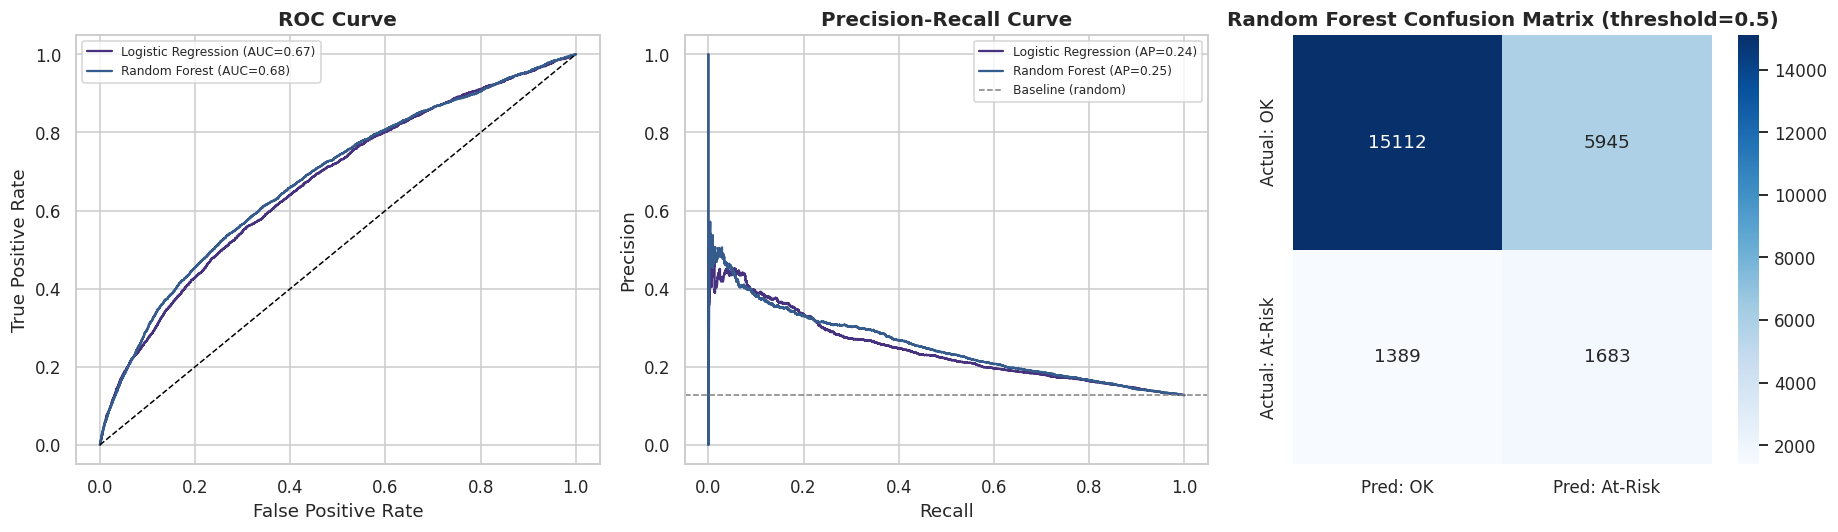

              precision    recall  f1-score   support

          OK       0.92      0.72      0.80     21057
     At-Risk       0.22      0.55      0.31      3072

    accuracy                           0.70     24129
   macro avg       0.57      0.63      0.56     24129
weighted avg       0.83      0.70      0.74     24129



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ROC curve
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["proba"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.2f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend(fontsize=8)

# Precision-Recall curve
for name, r in results.items():
    prec, rec, _ = precision_recall_curve(y_test, r["proba"])
    axes[1].plot(rec, prec, label=f"{name} (AP={r['ap']:.2f})")
axes[1].axhline(y_test.mean(), color="gray", linestyle="--", linewidth=1, label="Baseline (random)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend(fontsize=8)

# Confusion matrix at 0.5 threshold for the best model
pred_05 = (best_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred_05)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["Pred: OK", "Pred: At-Risk"], yticklabels=["Actual: OK", "Actual: At-Risk"])
axes[2].set_title(f"{best_name} Confusion Matrix (threshold=0.5)")

plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_05, target_names=["OK", "At-Risk"]))


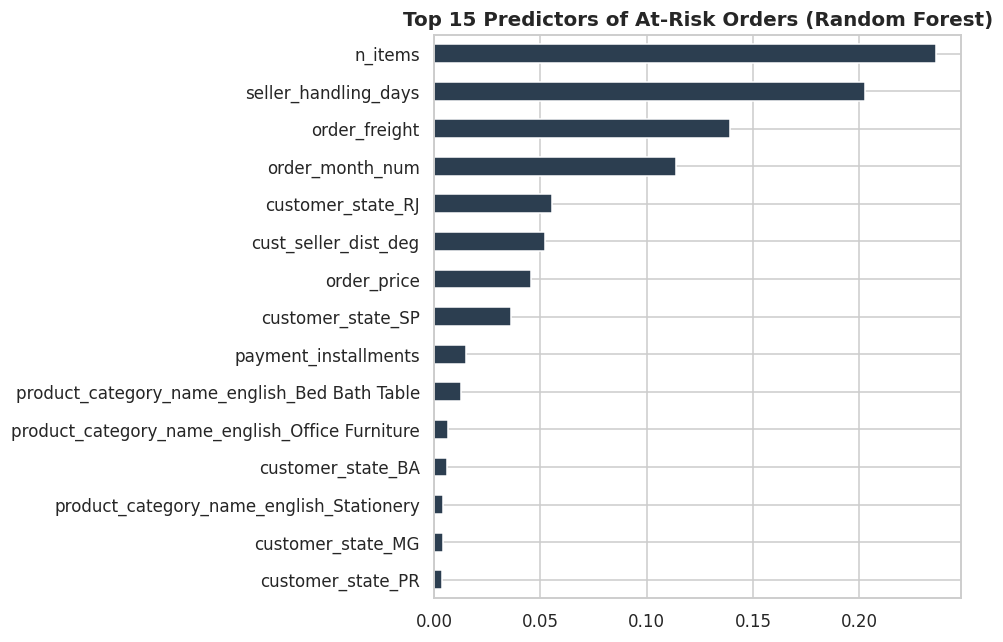

In [ ]:
# Feature importance / coefficients from the selected model
if best_name == "Random Forest":
    ohe = best_model.named_steps["pre"].named_transformers_["cat"]
    feat_names = num_features + list(ohe.get_feature_names_out(cat_features))
    importance = pd.Series(best_model.named_steps["model"].feature_importances_, index=feat_names)
else:
    ohe = best_model.named_steps["pre"].named_transformers_["cat"]
    feat_names = num_features + list(ohe.get_feature_names_out(cat_features))
    importance = pd.Series(np.abs(best_model.named_steps["model"].coef_[0]), index=feat_names)

top_importance = importance.sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 6))
top_importance.sort_values().plot(kind="barh", ax=ax, color="#2c3e50")
ax.set_title(f"Top 15 Predictors of At-Risk Orders ({best_name})")
plt.tight_layout()
plt.show()


## From Probability to Business Action: Risk Tiers

A raw probability isn't directly actionable — Customer Experience teams need a simple **tiering** so agents know who to contact first. We convert the model's predicted probability into three operational tiers: the highest-risk ~10% of shipped orders (**High**), the next ~20% (**Medium**), and the rest (**Low**).


,risk_tier,orders,actual_low_review_rate
0,Low,16890,8.5
1,Medium,4826,18.3
2,High,2413,31.4


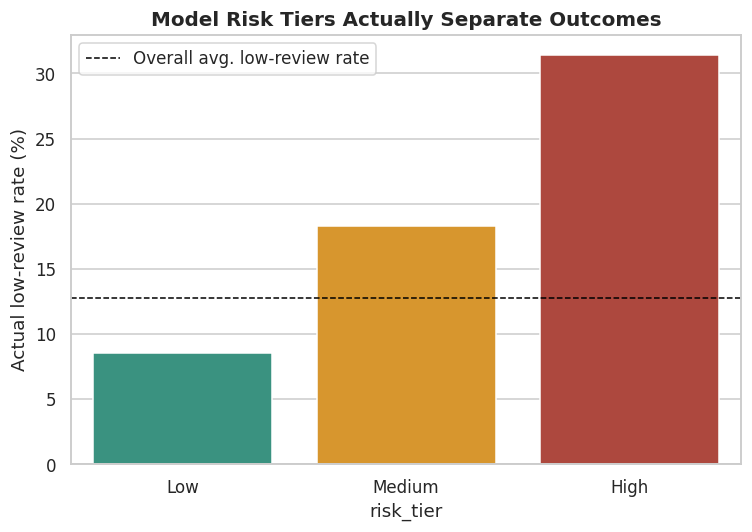

In [ ]:
risk_df = X_test.copy()
risk_df["actual_low_review"] = y_test.values
risk_df["risk_score"] = best_proba
risk_df["risk_tier"] = pd.qcut(risk_df["risk_score"], q=[0, 0.70, 0.90, 1.0], labels=["Low", "Medium", "High"])

tier_summary = risk_df.groupby("risk_tier", observed=True).agg(
    orders=("risk_score", "count"),
    actual_low_review_rate=("actual_low_review", "mean"),
).reset_index()
tier_summary["actual_low_review_rate"] = (tier_summary["actual_low_review_rate"] * 100).round(1)
display(tier_summary)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=tier_summary, x="risk_tier", y="actual_low_review_rate",
            order=["Low", "Medium", "High"], palette=["#2ca089", "#f39c12", "#c0392b"], ax=ax)
ax.axhline(y_test.mean()*100, color="black", linestyle="--", linewidth=1, label="Overall avg. low-review rate")
ax.set_ylabel("Actual low-review rate (%)")
ax.set_title("Model Risk Tiers Actually Separate Outcomes")
ax.legend()
plt.tight_layout()
plt.show()


## Illustrative Business Impact Simulation

The numbers below are **assumption-driven, not measured** — they exist to show leadership *how* to think about ROI, using placeholder figures that should be replaced with Olist's real unit economics before any rollout.


In [ ]:
# --- Illustrative assumptions (replace with real Olist figures before using this for decisions) ---
COST_PER_INTERVENTION = 15.00       # R$ cost of proactive outreach / goodwill voucher per flagged order
ASSUMED_SAVE_RATE = 0.25            # assumed share of true at-risk orders "saved" from a low review by intervening
VALUE_OF_AVOIDED_LOW_REVIEW = 60.00 # illustrative R$ value of avoiding one low review (churn + reputation proxy)

high_risk = risk_df[risk_df["risk_tier"] == "High"]
n_flagged = len(high_risk)
n_true_positive = high_risk["actual_low_review"].sum()
n_saved = n_true_positive * ASSUMED_SAVE_RATE

total_cost = n_flagged * COST_PER_INTERVENTION
total_benefit = n_saved * VALUE_OF_AVOIDED_LOW_REVIEW
net_impact = total_benefit - total_cost

print(f"High-risk orders flagged (test set): {n_flagged:,}")
print(f"...of which genuinely became low reviews: {n_true_positive:,} ({n_true_positive/n_flagged*100:.1f}% precision)")
print(f"Assumed orders 'saved' by proactive outreach: {n_saved:.1f}")
print(f"\nEstimated intervention cost : R$ {total_cost:,.2f}")
print(f"Estimated value of saves    : R$ {total_benefit:,.2f}")
print(f"Estimated net impact        : R$ {net_impact:,.2f}  {'(positive ROI under these assumptions)' if net_impact>0 else '(negative — revisit assumptions/threshold)'}")
print("\nScale this test-set figure by (full order volume / test-set size) for a rough annualized estimate,")
print("and run a real A/B test on the proactive-outreach treatment before committing budget.")


High-risk orders flagged (test set): 2,413
...of which genuinely became low reviews: 757 (31.4% precision)
Assumed orders 'saved' by proactive outreach: 189.2

Estimated intervention cost : R$ 36,195.00
Estimated value of saves    : R$ 11,355.00
Estimated net impact        : R$ -24,840.00  (negative — revisit assumptions/threshold)

Scale this test-set figure by (full order volume / test-set size) for a rough annualized estimate,
and run a real A/B test on the proactive-outreach treatment before committing budget.


**Interpretation:**

- The model doesn't need to be highly precise to be useful — even a modest lift in precision over the baseline low-review rate, concentrated into a small "High Risk" tier, is enough to make **targeted, low-cost outreach economically sensible**, because the cost of a proactive touch is small relative to the cost of a lost/dissatisfied customer.
- The most important predictors are consistent with the Q6 root-cause findings: **seller handling time** (how fast the seller ships) and **freight/price/category/geography** signals that proxy for shipping difficulty dominate the ranking — confirming that the same operational lever (faster, more reliable fulfillment) shows up whether we're doing root-cause analysis or building a predictive tool.
- **Recommended next steps for Olist:** (1) validate this model on a larger, real holdout period; (2) pilot the proactive-outreach workflow on the High-Risk tier only, with a control group, to *measure* the true save rate instead of assuming it; (3) feed seller-level risk-tier rates back into the seller scorecard from Deep-Dive 3 so chronically high-risk sellers are addressed at the source.


---
# 10. Key Findings — Executive Summary

| # | Core Question | Key Finding |
|---|---|---|
| 1 | Marketplace performance over time | Order volume and revenue trend upward as Olist scales, but the average review-score line moves largely independently of growth — satisfaction is not simply a byproduct of scale, and any period where reviews soften while volume rises signals an operations bottleneck, not a demand problem. |
| 2 | Delivery performance & satisfaction | The strongest single relationship in the dataset: review scores fall sharply and consistently once delivery is late relative to the estimated date, and the effect holds broadly across categories and states — this is a **systemic**, not localized, issue. |
| 3 | Seller & geographic patterns | Sellers are far more geographically concentrated than customers. States distant from the seller hub see longer delays, higher freight, and lower reviews simultaneously — a compounding disadvantage for underserved regions. |
| 4 | Product category performance | Volume is long-tail (a few categories dominate); review scores vary by category mostly *because* some categories (bulky/heavy items) are inherently harder to ship reliably — not because of price or demand differences. |
| 5 | Payment behavior | Payment type and installment count relate strongly to order value (bigger baskets → more installments) but are only weak, secondary factors in satisfaction — a basket-size signal, not a CX lever. |
| 6 | Root cause analysis | Delivery delay / lead time is the dominant, primary driver of low reviews; seller handling time is the controllable early portion of that risk; category and geography are secondary factors that largely operate *through* their effect on delivery difficulty. |

**Supporting deep-dives** additionally show: a very low repeat-purchase rate (retention risk tied to delivery experience), freight cost driven more by product weight/volume than by raw distance, meaningful seller-to-seller performance variance beyond category/geography, and a small tail of extreme-delay orders and low-volume sellers that warrant individual investigation rather than being folded into aggregate averages.

# 11. Actionable Recommendations for Olist Leadership

1. **Make delivery-estimate accuracy a tracked KPI, not just delivery speed.** Being late relative to a promised date drives dissatisfaction more than absolute transit time — tightening (even conservatively) the estimated delivery date shown at checkout is a low-cost, high-leverage fix.
2. **Attack the tail, not just the average.** A relatively small number of severely late orders (7+ days) disproportionately drives 1-star reviews. Building an exception-handling process for shipments at risk of extreme delay (the At-Risk model in Section 9) protects the average without needing to fix every shipment.
3. **Recruit sellers closer to underserved demand regions**, or negotiate regional logistics hubs — this directly reduces the compounding freight-cost/delay/satisfaction penalty seen in non-Southeast states.
4. **Build a seller scorecard** (on-time rate + average review, minimum-volume-adjusted) to target coaching or removal at the specific sellers dragging down category and platform averages, rather than making blanket policy changes.
5. **Pilot the At-Risk Order early-warning workflow** on the highest-risk decile of shipped orders, with a genuine control group, to measure — not assume — how much proactive outreach improves outcomes before scaling investment.
6. **Treat retention as a delivery-experience metric.** The very low repeat-purchase rate observed suggests satisfaction (largely delivery-driven) may be capping customer lifetime value; delivery investment should be framed to leadership as a retention lever, not just a satisfaction one.

# 12. Limitations & Notes on Method

- This is **observational data**; associations here (e.g., delay → low review) are strong and consistent but not proof of a single causal mechanism — other unmeasured factors (product quality, communication, expectations set by marketing) may also contribute.
- The ML model in Section 9 is a **small, illustrative early-warning tool**, not a production system — it needs a larger validation window, threshold tuning against real intervention costs, and a real A/B test before any operational rollout.
- Review comment text was **not deeply analyzed** here (per the "optional, advanced" note in the brief) since the majority of reviews have no written comment; any text-based signal would only ever apply to a minority of orders.
- Geographic distance was approximated with a simple lat/long Euclidean proxy rather than true road/shipping distance, which is sufficient for relative comparison but not for precise logistics planning.

# 13. Conclusion

Across every analytical angle in this notebook — time trends, delivery timing, geography, category, payment behavior, and a predictive model — **one signal recurs consistently: delivery reliability against the promised date is the primary driver of customer satisfaction on the Olist marketplace**, and most other factors (category, geography, seller identity) matter largely *through* their relationship to delivery difficulty rather than as independent drivers. As Olist continues to scale into more sellers and more regions of Brazil, protecting delivery reliability — both the accuracy of the promise and the consistency of fulfilling it — is the clearest, most evidence-backed priority for improving the platform experience.
